In [7]:
# Imports and defininitions

# pipeline_for_spatial_reduction.py
import warnings
warnings.filterwarnings("ignore")

import geopandas as gpd
import pandas as pd
from pathlib import Path
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import kneighbors_graph, NearestNeighbors
from sklearn.cluster import AgglomerativeClustering, SpectralClustering, KMeans
from scipy.spatial.distance import cdist
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform
from scipy import sparse
import networkx as nx
import community as community_louvain  # python-louvain
from shapely.geometry import box
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.collections import LineCollection
from collections import defaultdict 
import libpysal
from libpysal.weights import Rook, Queen
from spopt.region import MaxPHeuristic as MaxP

# -------------------------
# 0. SETTINGS / PATHS
# -------------------------
# Replace these paths with your files

ATTRIBUTES_CSV = "../../../data_prep/data/UKR_attributes_3.csv"                                 # columns: cell_id, pop_density, wind_mean, solar_mean, ... 
HOURLY_CF_Solar = "../../../data_prep/era5_data/UKR_solar_power_profile_trimmed.csv"            # CSV solar timeseries
HOURLY_CF_Wind = "../../../data_prep/era5_data/UKR_wind_power_profile_trimmed.csv"              # CSV wind timeseries
K_NEIGHBORS = 10  # for KNN graph
PCA_COMPONENTS = 2
ALPHA = 0.1 # spatial penalty
BETA_ATTR = 0.4 # attributes penalty (can be split)
CRS_METRIC = "EPSG:3035"  # ETRS89 / LAEA Europe
clustering_type = 'Agglomerative'  # Change as needed: 'Agglomerative', 'Spectral', 'Louvain', 'Hierarchical', 'MaxP_spopt', 'MaxP_custom'

n_clusters_target = 6  # change as needed
save_output = False # Set to False to skip saving
floor_timeseries = True # whether to zero tiny CF values in the timeseries to avoid downstream coefficient magnitude issues

if save_output == True:
    OUTPUT_DIR = f"../../../data_prep/Clustering_Output/KNN_Graph_output/nodal_ammonia_bidirectional/{clustering_type}/{clustering_type}_k{n_clusters_target}/"  # Output directory for saving results
    Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)

In [8]:
# Creates the geojson file with 0.25 x 0.25 degree cells coveirng Ukraine. 
# Each cell is represented as a square polygon centered on the lat/lon coordinates.
# The attributes contained in the input CSV are preserved and included in the output GeoJSON.

def centroids_to_squares(df, lon_col='lon', lat_col='lat', dx=0.25):
    half = dx / 2.0
    df['geometry'] = df.apply(lambda r: box(r[lon_col]-half, r[lat_col]-half,
                                           r[lon_col]+half, r[lat_col]+half), axis=1)
    gdf = gpd.GeoDataFrame(df, geometry='geometry', crs="EPSG:4326")
    return gdf

attrs = pd.read_csv(ATTRIBUTES_CSV)

if 'cell_id' not in attrs.columns:
    attrs['cell_id'] = attrs['lat'].astype(str) + '_' + attrs['lon'].astype(str)
    
gdf = centroids_to_squares(attrs, lon_col='lon', lat_col='lat', dx=0.25)

# Save fresh GeoJSON (no region assignments)
gdf.to_file("../../../data_prep/data/ukraine_cells.geojson", driver="GeoJSON")

print(f"Created GeoJSON with {len(gdf)} cells")

Created GeoJSON with 1180 cells


In [9]:
# -------------------------
# 1. LOAD DATA
# -------------------------

hourly_solar = pd.read_csv(HOURLY_CF_Solar, index_col=0, parse_dates=True)  # index: datetime, columns: cell_id
hourly_wind = pd.read_csv(HOURLY_CF_Wind, index_col=0, parse_dates=True)      # index: datetime, columns: cell_id

# ensure indexing align
gdf = gdf.set_index("cell_id")
cell_ids = gdf.index.to_numpy()
n = len(gdf)

# -------------------------
# 2. REPROJECT TO METRIC - EPSG:3035
# -------------------------
gdf = gdf.to_crs(CRS_METRIC)
coords = np.vstack([gdf.geometry.centroid.x, gdf.geometry.centroid.y]).T

# -------------------------
# 3. BUILD ATTRIBUTE MATRIX
# -------------------------
# Choose attributes you want to include. Example:
# attr_cols = ["wind_cf_mean", "solar_cf_std", "wind_cf_mean", "wind_cf_std",'population','pc1','pc2','available_land_area_km2']  # ensure these exist in attrs
attr_cols = ["wind_cf_mean", "solar_cf_mean",'avg_equiv_demand_MWh','pc1','pc2','available_land_area_km2']

# Fill NaN values with column medians
for col in attr_cols:
    if gdf[col].isna().any():
        median_val = gdf[col].median()
        print(f"Filling {gdf[col].isna().sum()} NaN in '{col}' with median: {median_val:.4f}")
        gdf[col] = gdf[col].fillna(median_val)

X_basic = gdf[attr_cols].values  # (n, k)

# attr_cols = ['wind_cf', 'solar_cf', 'population', 'pc1', 'pc2', 'available_land_area']
#              index:  0          1          2       3      4            5

X = np.hstack([
    np.log1p(X_basic[:, [2]]),  # log(1 + avg_equiv_demand_MWh) - column 2
    X_basic[:, 1:2],             # solar_cf_mean - column 1
    X_basic[:, :1],              # wind_cf_mean - column 0
    X_basic[:, 3:6]              # pc1, pc2, available_land_area_km2 - columns 3-5
])

scaler = StandardScaler()
Z = scaler.fit_transform(X)   # standardized attribute matrix 

# -------------------------
# 4. BUILD k-NN GRAPH (spatial)
# -------------------------
A = kneighbors_graph(coords, n_neighbors=K_NEIGHBORS, include_self=False, mode='connectivity')
A = A.toarray()  # adjacency matrix (0/1)

# optionally symmetrise
A = np.maximum(A, A.T)

# -------------------------
# Helper: normalized median neighbor distance
# -------------------------
# compute median distance to 1st neighbor for normalization
nn = NearestNeighbors(n_neighbors=2).fit(coords)
dists, idxs = nn.kneighbors(coords)
median_nn = np.median(dists[:,1])

# -------------------------
# 5. EDGE WEIGHTS (alpha/beta)
# -------------------------
def compute_weighted_adj(A, coords, Z, alpha=ALPHA, beta=BETA_ATTR, median_nn=median_nn):
    d_geo_list = []
    d_attr_list = []
    n = A.shape[0]
    W = np.zeros_like(A, dtype=float)
    for i in range(n):
        js = np.where(A[i] > 0)[0]
        for j in js:
            d_geo = (np.linalg.norm(coords[i] - coords[j]) / median_nn)
            d_geo_list.append(d_geo)
            d_attr = np.linalg.norm(Z[i] - Z[j])
            d_attr_list.append(d_attr)
            W[i, j] = np.exp(-alpha * d_geo - beta * d_attr)  # ← exponent unbounded
    W = np.maximum(W, W.T)
    return W, d_geo_list, d_attr_list

W, d_geo_list, d_attr_list = compute_weighted_adj(A, coords, Z, alpha=ALPHA, beta=BETA_ATTR)

print(f'Average distance to 1st neighbor (for normalization): {np.average(d_geo_list):.4f}')
print(f'Distance sd to 1st neighbor (for normalization): {np.std(d_geo_list):.4f}')
print(f'Average attribute distance: {np.average(d_attr_list):.4f}')
print(f'Attribute distance sd: {np.std(d_attr_list):.4f}')


# build networkx graph for community algorithms
Gnx = nx.from_numpy_array(W)
mapping = {i: cell_ids[i] for i in range(n)}
Gnx = nx.relabel_nodes(Gnx, mapping)

# Build queen contiguity from the actual geometry
A_queen_weights = Queen.from_dataframe(gdf.reset_index(), use_index=False)
A_queen = A_queen_weights.full()[0]  # Convert to dense numpy array

print(f"KNN adjacency: {int(A.sum())} edges (avg {A.sum()/len(gdf):.1f} per cell)")

# For MaxP_spopt, use A_queen instead of A for true contiguity
# Original KNN adjacency (A) is still used for weighted methods (Spectral, etc.)

# Rook contiguity: only cells sharing an EDGE are adjacent (not corners)
# Queen = 8 neighbors (edges + corners), Rook = 4 neighbors (edges only)
A_rook_weights = Rook.from_dataframe(gdf.reset_index(), use_index=False)
A_rook = A_rook_weights.full()[0]

print(f"Queen adjacency: {int(A_queen.sum())} edges (avg {A_queen.sum()/len(gdf):.1f} per cell)")
print(f"Rook adjacency: {int(A_rook.sum())} edges (avg {A_rook.sum()/len(gdf):.1f} per cell)")

Average distance to 1st neighbor (for normalization): 1.7827
Distance sd to 1st neighbor (for normalization): 0.5473
Average attribute distance: 1.1972
Attribute distance sd: 1.4184
KNN adjacency: 12412 edges (avg 10.5 per cell)
Queen adjacency: 8742 edges (avg 7.4 per cell)
Rook adjacency: 4436 edges (avg 3.8 per cell)


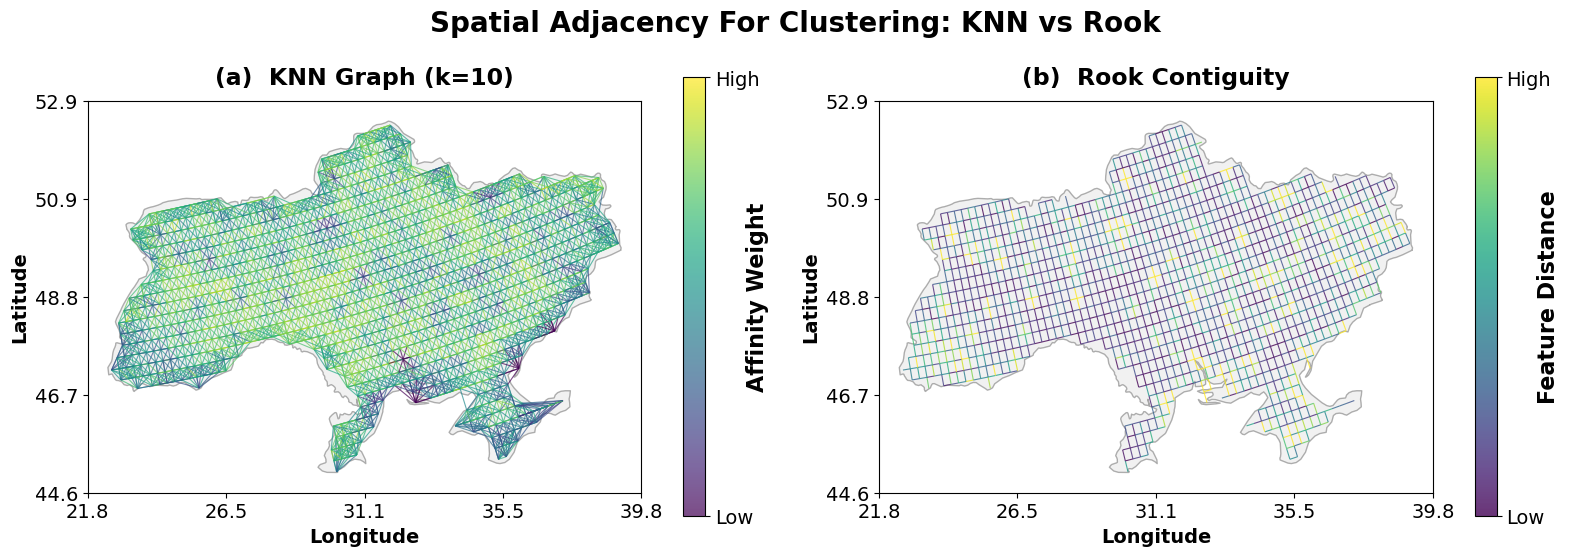

KNN edges: 6206,  weight range: 0.0010 – 0.8793
Rook edges: 2218,  feature dist range: 0.07 – 16.68


In [10]:
# ── Side-by-side: KNN + Affinity kernel  |  Rook + Feature distance ──

import matplotlib.colors as mcolors
from matplotlib.collections import LineCollection
from pyproj import Transformer

from pyproj import Transformer

transformer = Transformer.from_crs("EPSG:3035", "EPSG:4326", always_xy=True)

def set_latlon_ticks(ax, nticks=5):
    """Replace EPSG:3035 tick labels with lat/lon in degrees."""
    xticks = np.linspace(*ax.get_xlim(), nticks)
    yticks = np.linspace(*ax.get_ylim(), nticks)
    
    # Transform to lon/lat
    xlon, _ = transformer.transform(xticks, np.full_like(xticks, np.mean(ax.get_ylim())))
    _, ylat = transformer.transform(np.full_like(yticks, np.mean(ax.get_xlim())), yticks)
    
    ax.set_xticks(xticks)
    ax.set_xticklabels([f'{lon:.1f}' for lon in xlon], fontsize=14)
    ax.set_yticks(yticks)
    ax.set_yticklabels([f'{lat:.1f}' for lat in ylat], fontsize=14)
    ax.set_xlabel('Longitude', fontsize=14, fontweight='bold')
    ax.set_ylabel('Latitude', fontsize=14, fontweight='bold')

UKR_SHP = "../../../data_prep/data/ukraine_merged_dissolved_noholes.geojson"
ukr_boundary = gpd.read_file(UKR_SHP).to_crs(CRS_METRIC)
xmin, ymin, xmax, ymax = ukr_boundary.total_bounds
pad = 50000

plt.rcParams.update({'font.size': 10})
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# ── Panel 1: KNN edges coloured by affinity W ──
edges_knn, weights_knn = [], []
for i in range(n):
    for j in np.where(A[i] > 0)[0]:
        if i < j:
            edges_knn.append([coords[i], coords[j]])
            weights_knn.append(W[i, j])

weights_knn = np.array(weights_knn)
norm_knn = mcolors.Normalize(vmin=weights_knn.min(), vmax=weights_knn.max())

ukr_boundary.plot(ax=ax1, color='lightgrey', edgecolor='black', alpha=0.3, zorder=1)
lc1 = LineCollection(edges_knn, cmap='viridis', norm=norm_knn, linewidths=0.8, alpha=0.7, zorder=2)
lc1.set_array(weights_knn)
ax1.add_collection(lc1)
# ax1.scatter(coords[:, 0], coords[:, 1], s=8, c='black', alpha=0.5, zorder=3)
cbar1 = plt.colorbar(lc1, ax=ax1, shrink=0.7, pad=0.06)
cbar1.set_label('Affinity Weight', fontsize=16, fontweight='bold', labelpad=-10)
cbar1.set_ticks([weights_knn.min(), weights_knn.max()])
cbar1.set_ticklabels(['Low', 'High'], fontsize=14)
ax1.set_xlim(xmin - pad, xmax + pad)
ax1.set_ylim(ymin - pad, ymax + pad)
set_latlon_ticks(ax1)
ax1.set_title(f'(a)  KNN Graph (k={K_NEIGHBORS})', fontsize=17, fontweight='bold', y=1.02)
ax1.set_aspect('equal')

# ── Panel 2: Rook edges coloured by feature distance ||Z_i - Z_j|| ──
edges_rook, dists_rook = [], []
for i in range(n):
    for j in np.where(A_rook[i] > 0)[0]:
        if i < j:
            edges_rook.append([coords[i], coords[j]])
            dists_rook.append(np.linalg.norm(Z[i] - Z[j]))

dists_rook = np.array(dists_rook)

# Clip to 5th–95th percentile for contrast, linear scale
vmin_r = np.percentile(dists_rook, 5)
vmax_r = np.percentile(dists_rook, 95)
norm_rook = mcolors.Normalize(vmin=vmin_r, vmax=vmax_r)

ukr_boundary.plot(ax=ax2, color='lightgrey', edgecolor='black', alpha=0.3, zorder=1)
lc2 = LineCollection(edges_rook, cmap='viridis', norm=norm_rook, linewidths=0.8, alpha=0.8, zorder=2)
lc2.set_array(dists_rook)
ax2.add_collection(lc2)
# ax2.scatter(coords[:, 0], coords[:, 1], s=8, c='black', alpha=0.5, zorder=3)
cbar2 = plt.colorbar(lc2, ax=ax2, shrink=0.7, pad=0.06)
cbar2.set_label('Feature Distance', fontsize=16, fontweight='bold', labelpad=-10)
cbar2.set_ticks([vmin_r, vmax_r])
cbar2.set_ticklabels(['Low', 'High'], fontsize=14)
ax2.set_xlim(xmin - pad, xmax + pad)
ax2.set_ylim(ymin - pad, ymax + pad)
set_latlon_ticks(ax2)
ax2.set_title(f'(b)  Rook Contiguity', fontsize=17, fontweight='bold', y=1.02)
ax2.set_aspect('equal')
plt.suptitle('Spatial Adjacency For Clustering: KNN vs Rook', fontsize=20, fontweight='bold', y = 0.88)
plt.tight_layout()
plt.savefig("../../../4YP_Figures/knn_rook_adjacency_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"KNN edges: {len(edges_knn)},  weight range: {weights_knn.min():.4f} – {weights_knn.max():.4f}")
print(f"Rook edges: {len(edges_rook)},  feature dist range: {dists_rook.min():.2f} – {dists_rook.max():.2f}")

In [11]:

# -------------------------
# 6. CLUSTERING (several options)
# -------------------------
# connectivity = csr_matrix(A)

def run_kmeans_spatial(coords, n_clusters):
    """K-means clustering based only on geographic coordinates (EPSG:3035 centroids)."""
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    labels = kmeans.fit_predict(coords)
    return labels

def run_kmeans_features(Z, n_clusters):
    """K-means clustering based on the standardized attribute feature matrix."""
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    labels = kmeans.fit_predict(Z)
    return labels

def run_ward_contiguous(Z, A_rook, n_clusters_target, verbose=True):
    """
    Ward clustering with Rook contiguity constraint and singleton merging.
    """
    connectivity_rook = csr_matrix(A_rook)
    D = cdist(Z, Z, metric='euclidean')
    
    agg = AgglomerativeClustering(
        n_clusters=n_clusters_target,
        linkage='ward',
        connectivity=connectivity_rook
    )
    labels = agg.fit_predict(Z)
    
    labels = _merge_singletons_contiguous(labels, A_rook, D, verbose=verbose)
    labels = _make_labels_consecutive(labels)
    
    n_actual = len(np.unique(labels))
    if verbose:
        print(f"Ward Rook: requested {n_clusters_target}, got {n_actual} clusters after singleton merging")
    
    return labels

def run_kmeans_spatial_features(coords, Z, n_clusters, spatial_weight=1.0):
    """K-means clustering on combined standardized spatial coordinates and attribute features.
    
    Parameters
    ----------
    coords : (n,2) array of EPSG:3035 centroids
    Z : (n,m) standardized attribute feature matrix
    n_clusters : int
    spatial_weight : float
        Weight applied to standardized coordinates before concatenation.
        Higher values give more importance to spatial proximity.
    """
    coords_std = StandardScaler().fit_transform(coords)
    Z_combined = np.hstack([spatial_weight * coords_std, Z])
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    labels = kmeans.fit_predict(Z_combined)
    return labels

def run_agglomerative(Z, connectivity, n_clusters, A_contiguity=A_rook):
    """Agglomerative clustering with simple singleton merging."""
    
    for k_try in range(n_clusters, n_clusters + 10):
        agg = AgglomerativeClustering(n_clusters=k_try, linkage='ward', connectivity=connectivity)
        labels = agg.fit_predict(Z)
        
        # Merge singletons into nearest adjacent cluster
        if A_contiguity is not None:
            changed = True
            while changed:
                changed = False
                unique, counts = np.unique(labels, return_counts=True)
                for cid in unique[counts == 1]:
                    idx = np.where(labels == cid)[0][0]
                    neighbors = np.where(A_contiguity[idx] > 0)[0]
                    neighbor_labels = [labels[n] for n in neighbors if labels[n] != cid]
                    if neighbor_labels:
                        labels[idx] = neighbor_labels[0]
                        changed = True
        
        # Relabel consecutively
        for new, old in enumerate(np.unique(labels)):
            labels[labels == old] = new
        
        if len(np.unique(labels)) == n_clusters:
            return labels
    
    return labels  # best effort


def _merge_singletons_contiguous(labels, A_contiguity, D, verbose=False):
    """
    Merge singleton clusters into adjacent clusters based on spatial contiguity.
    
    If a singleton has no contiguous neighbors (edge case), falls back to nearest by distance.
    """
    labels = labels.copy()
    max_passes = 100  # Safety limit
    
    for pass_num in range(max_passes):
        unique, counts = np.unique(labels, return_counts=True)
        singletons = unique[counts == 1]
        
        if len(singletons) == 0:
            break  # No more singletons
            
        if verbose:
            print(f"  Pass {pass_num + 1}: {len(singletons)} singletons to merge")
        
        merged_any = False
        for singleton_id in singletons:
            singleton_idx = np.where(labels == singleton_id)[0][0]
            
            # Find contiguous neighbors (cells adjacent in space)
            if A_contiguity is not None:
                neighbors = np.where(A_contiguity[singleton_idx] > 0)[0]
            else:
                neighbors = np.array([])
            
            # Filter to neighbors in DIFFERENT clusters
            neighbor_clusters = [(n, labels[n]) for n in neighbors if labels[n] != singleton_id]
            
            if len(neighbor_clusters) > 0:
                # Pick neighbor with minimum distance (best affinity) among contiguous options
                best_neighbor = min(neighbor_clusters, key=lambda x: D[singleton_idx, x[0]])
                labels[singleton_idx] = best_neighbor[1]
                merged_any = True
            else:
                # Fallback: no contiguous neighbors, use global nearest (shouldn't happen often)
                nearest_neighbors = np.argsort(D[singleton_idx, :])
                for nn_idx in nearest_neighbors:
                    if labels[nn_idx] != singleton_id:
                        labels[singleton_idx] = labels[nn_idx]
                        merged_any = True
                        break
        
        if not merged_any:
            break  # No progress possible
    
    return labels


def _make_labels_consecutive(labels):
    """Remap labels to be consecutive integers starting from 0."""
    unique = np.unique(labels)
    label_map = {old: new for new, old in enumerate(unique)}
    return np.array([label_map[x] for x in labels])

def run_spectral_on_W(W, n_clusters, n_embed=None):
    spec = SpectralClustering(n_clusters=n_clusters, n_components=n_embed, affinity='precomputed', assign_labels='kmeans')
    labels = spec.fit_predict(W)
    return labels

def run_louvain(Gnx):
    partition = community_louvain.best_partition(Gnx, weight='weight', resolution=1.0)
    # returns mapping cell_id -> community_id
    labels = pd.Series(partition).reindex(cell_ids).values
    return labels

def run_hierarchical_on_W(W, n_clusters):
    """Hierarchical clustering using weighted affinity"""
    D = -np.log(np.clip(W, 1e-12, 1.0))
    np.fill_diagonal(D, 0.0)
    D_condensed = squareform(D, checks=False)
    Z_linkage = linkage(D_condensed, method='average')
    labels = fcluster(Z_linkage, n_clusters, criterion='maxclust') - 1
    return labels

def run_hierarchical_auto_k(W, n_clusters_target, max_iterations=50, verbose=True):
    """
    Hierarchical clustering with automatic K adjustment to reach target cluster count.
    
    Iteratively increases/decreases the internal K value until we get exactly 
    n_clusters_target clusters after merging singletons.
    
    Parameters:
    -----------
    W : ndarray
        Precomputed weighted affinity matrix
    n_clusters_target : int
        Target number of clusters after merging singletons
    max_iterations : int
        Maximum iterations to search for correct K
    verbose : bool
        Print progress
        
    Returns:
    --------
    labels : ndarray
        Cluster labels with exactly n_clusters_target clusters
    k_internal : int
        The internal K value that produced the target
    """
    
    
    # Binary search for the right k_internal
    k_low = n_clusters_target
    k_high = len(W)  # maximum possible (one cluster per node)
    k_internal = n_clusters_target
    
    for iteration in range(max_iterations):
        # Run hierarchical clustering with current k_internal
        D = 1 - (W / np.max(W))  # convert affinity to distance
        D_condensed = squareform(D, checks=False)
        Z_linkage = linkage(D_condensed, method='average')
        labels = fcluster(Z_linkage, k_internal, criterion='maxclust') - 1
        
        # Merge singletons
        unique, counts = np.unique(labels, return_counts=True)
        singletons = unique[counts == 1]
        D_sq = D  # Use full distance matrix for nearest neighbor search
        
        for singleton_id in singletons:
            singleton_idx = np.where(labels == singleton_id)[0][0]
            nearest_neighbors = np.argsort(D_sq[singleton_idx, :])
            for nn_idx in nearest_neighbors:
                if labels[nn_idx] != singleton_id:
                    labels[singleton_idx] = labels[nn_idx]
                    break
        
        # Count unique clusters after merging
        n_clusters_actual = len(np.unique(labels))
        
        if verbose:
            print(f"Iteration {iteration + 1}: k_internal={k_internal:3d} → {n_clusters_actual:3d} clusters after merging")
        
        # Check if we achieved target
        if n_clusters_actual == n_clusters_target:
            if verbose:
                print(f"✓ Success! Found k_internal={k_internal} produces {n_clusters_target} clusters")
            return labels, k_internal
        
        # Adjust k_internal
        if n_clusters_actual < n_clusters_target:
            # Too few clusters, need to increase k_internal
            k_low = k_internal
            k_internal = (k_internal + k_high) // 2
        else:
            # Too many clusters, need to decrease k_internal
            k_high = k_internal
            k_internal = (k_internal + k_low) // 2
        
        # Check for convergence
        if k_low == k_internal or k_high == k_internal:
            if verbose:
                print(f"⚠ Search converged at k_internal={k_internal} with {n_clusters_actual} clusters")
                print(f"  (Target was {n_clusters_target}, diff = {n_clusters_actual - n_clusters_target})")
            return labels, k_internal
    
    if verbose:
        print(f"✗ Max iterations reached. Last k_internal={k_internal} produced {n_clusters_actual} clusters")
    return labels, k_internal

# The max-p clustering (Not PySAL) - From MrGPT 

def ensure_csr(M):
    if sparse.issparse(M):
        return M.tocsr()
    else:
        return sparse.csr_matrix(M)

def maxp_region_growing(A, W, pop, threshold=None, K_target=None, seed_strategy='pop_desc', objective='mean'):
    """
    Max-p style greedy region-growing using contiguity matrix A and affinity W.
    Args:
        A: (n,n) binary adjacency (numpy array or csr_matrix) - contiguity used for frontier expansion
        W: (n,n) affinity weights (numpy array or csr_matrix) - higher = more similar
        pop: (n,) population array
        threshold: explicit population threshold (scalar). If None and K_target given, derived from total pop.
        K_target: if threshold is None, use total_pop / K_target
        seed_strategy: 'pop_desc' (default)
        objective: 'mean' or 'sum' internal affinity (affects tie-break)
    Returns:
        labels: int array length n with cluster ids
    """
    n = len(pop)
    assert (W.shape[0] == n) and (A.shape[0] == n)
    pop = np.asarray(pop, dtype=float)

    # compute threshold if needed
    total_pop = pop.sum()
    if threshold is None:
        if K_target is None:
            raise ValueError("Either threshold or K_target must be provided")
        threshold = total_pop / float(K_target)

    # ensure sparse format for neighbourhood operations
    A = ensure_csr(A)
    W = ensure_csr(W)

    assigned = -np.ones(n, dtype=int)
    cluster_id = 0

    # seeds: order nodes by descending population
    if seed_strategy == 'pop_desc':
        seeds = np.argsort(-pop)
    else:
        seeds = np.arange(n)

    # helper: compute internal affinity quickly using sparse sums
    # cluster_mask: boolean array length n
    def internal_affinity_sum(cluster_mask):
        # returns sum of weights inside cluster (undirected edges counted once)
        idx = np.where(cluster_mask)[0]
        if len(idx) <= 1:
            return 0.0
        sub = W[idx, :][:, idx]  # sparse submatrix
        s = sub.sum() / 2.0
        return float(s)

    def internal_affinity_mean(cluster_mask):
        idx = np.where(cluster_mask)[0]
        if len(idx) <= 1:
            return 0.0
        pairs = len(idx) * (len(idx) - 1) / 2.0
        s = internal_affinity_sum(cluster_mask)
        return s / pairs

    # main grow loop
    for seed in seeds:
        if assigned[seed] != -1:
            continue

        # start cluster
        cluster_nodes = [seed]
        assigned[seed] = cluster_id
        cluster_pop = pop[seed]

        # boolean mask for cluster nodes (for fast indexing)
        cluster_mask = np.zeros(n, dtype=bool)
        cluster_mask[seed] = True

        # frontier: neighbors (from A) of current cluster that are unassigned
        frontier = set(A[seed].nonzero()[1].tolist())
        frontier = {v for v in frontier if assigned[v] == -1}

        # grow until threshold met or frontier exhausted
        while cluster_pop < threshold and frontier:
            # compute score for each frontier node efficiently:
            # score = mean affinity between v and current cluster nodes
            front_list = np.array(list(frontier), dtype=int)
            # W[front_list][:, cluster_mask] sum across columns gives affinity to cluster
            if cluster_mask.sum() == 0:
                # shouldn't happen
                scores = np.zeros(len(front_list))
            else:
                # use sparse multiplication: for vector of ones over cluster nodes
                cluster_idx = np.where(cluster_mask)[0]
                # create vector with ones at cluster indices
                ones = np.zeros(n, dtype=float)
                ones[cluster_idx] = 1.0
                # compute affinity sums: row * ones = sum of weights to cluster nodes
                # but do it only for frontier rows for memory efficiency
                # Extract rows for frontier
                W_front = W[front_list, :]
                aff_sums = W_front.dot(ones)  # shape (len(front_list),)
                if objective == 'mean':
                    if len(cluster_idx) > 1:
                        scores = np.asarray(aff_sums).ravel() / len(cluster_idx)
                    else:
                        scores = np.asarray(aff_sums).ravel()  # single node cluster
                else:  # 'sum'
                    scores = np.asarray(aff_sums).ravel()

            # choose best frontier node by highest score, tie-break by pop
            best_idx = np.argmax(scores)
            best_v = int(front_list[best_idx])

            # add best_v
            cluster_nodes.append(best_v)
            assigned[best_v] = cluster_id
            cluster_pop += pop[best_v]
            cluster_mask[best_v] = True

            # update frontier: add unassigned neighbors of best_v, remove added
            neighs = set(A[best_v].nonzero()[1].tolist())
            for nb in neighs:
                if assigned[nb] == -1:
                    frontier.add(nb)
            frontier.discard(best_v)
            # also prune any frontier nodes that became assigned due to other logic
            frontier = {v for v in frontier if assigned[v] == -1}

        cluster_id += 1

    # postprocess: merge clusters with population < threshold into best neighbor cluster
    labels = assigned.copy()
    # compute cluster pops
    unique, counts = np.unique(labels[labels >= 0], return_counts=True)
    cluster_pops = {cid: pop[labels == cid].sum() for cid in unique}

    small_clusters = [cid for cid,p in cluster_pops.items() if p < threshold]
    for sc in small_clusters:
        members = np.where(labels == sc)[0]
        # find neighboring clusters and affinity
        neighbor_aff = defaultdict(float)
        for m in members:
            # neighbors via A
            neighs = A[m].nonzero()[1]
            for nb in neighs:
                nb = int(nb)
                cid = labels[nb]
                if cid == sc or cid == -1:
                    continue
                # add affinity of m to that cluster (approx sum of weights to nodes in that cluster)
                # using W row
                mask = (labels == cid)
                if mask.sum() == 0:
                    continue
                neighbor_aff[cid] += W[m, :].toarray().ravel()[mask].sum()
        if neighbor_aff:
            target = max(neighbor_aff.items(), key=lambda x: x[1])[0]
            labels[members] = target
        else:
            # no labeled neighbors (isolated). attach to nearest by W weights
            for m in members:
                row = W[m, :].toarray().ravel()
                # pick index of highest-weight neighbor that's assigned
                idxs = np.argsort(-row)
                for cand in idxs:
                    if labels[cand] != sc and labels[cand] != -1:
                        labels[m] = labels[cand]
                        break

    # final relabeling compact ids
    uniq = np.unique(labels[labels >= 0])
    id_map = {old: new for new, old in enumerate(uniq)}
    final_labels = np.full(n, -1, dtype=int)
    for i in range(n):
        if labels[i] >= 0:
            final_labels[i] = id_map[labels[i]]
        else:
            # fallback attach to nearest assigned by W
            row = W[i, :].toarray().ravel()
            cand = np.argmax(row)
            final_labels[i] = id_map[labels[cand]]

    return final_labels

# Spopt MaxP

def build_libpysal_W_from_A(A, n=None):
    """
    Build libpysal.weights.W from adjacency matrix A.
    A: (n,n) dense numpy array or scipy.sparse matrix (0/1 entries)
    n: optional explicit number of nodes (useful if A omits isolated rows)
    Returns: libpysal.weights.W object
    """
    # accept sparse or dense
    if sparse.issparse(A):
        A_coo = A.tocoo()
        rows = A_coo.row.astype(int).tolist()
        cols = A_coo.col.astype(int).tolist()
    else:
        A = np.asarray(A)
        rows, cols = np.where(A > 0)
        rows = rows.astype(int).tolist()
        cols = cols.astype(int).tolist()

    if n is None:
        if len(rows) == 0 and len(cols) == 0:
            raise ValueError("Adjacency appears empty; pass n explicitly (n = len(df_cells)).")
        n = max(max(rows) if rows else -1, max(cols) if cols else -1) + 1

    # build neighbor dict ensuring every node 0..n-1 present
    neigh = {i: [] for i in range(n)}
    for r, c in zip(rows, cols):
        if r == c:
            continue
        neigh[int(r)].append(int(c))

    # make entries unique and sorted (optional)
    for k, lst in neigh.items():
        if len(lst) > 1:
            seen = set()
            uniq = []
            for x in lst:
                if x not in seen:
                    seen.add(x)
                    uniq.append(x)
            neigh[k] = uniq

    # Build libpysal W object from neighbor dict
    W_obj = libpysal.weights.W(neigh)
    return W_obj

# Drop-in function to run spopt MaxP and attach results to df_cells
def run_spopt_maxp(
    df_cells,
    A,
    feature_array=None,
    feature_cols=None,
    pop_col='population',
    threshold=None,
    K_target=None,
    top_n=5,
    max_iterations_construction=200,
    max_iterations_sa=50,
    verbose=True,
    assign_column='cluster_spopt'
    ):
    """
    Run spopt MaxPHeuristic using existing contiguity matrix A and features.
    
    Parameters
    ----------
    df_cells : geopandas.GeoDataFrame
        GeoDataFrame indexed 0..n-1 containing geometry and population column.
    A : array-like or scipy.sparse matrix (n,n)
        Binary contiguity matrix where A[i,j] == 1 indicates adjacency/contiguity.
    feature_array : (n, m) numpy array, optional
        Normalised feature matrix to use for region homogeneity. If provided,
        these columns will be added to df_cells as feat_0..feat_{m-1}.
    feature_cols : list of str, optional
        If you already have normalized feature columns inside df_cells, pass their names here.
        Either feature_array or feature_cols must be provided.
    pop_col : str
        Column name in df_cells containing the spatially extensive threshold attribute (population).
    threshold : float, optional
        Absolute minimum population per region. If None, must provide K_target.
    K_target : int, optional
        If threshold is None, threshold = total_pop / K_target.
    top_n, max_iterations_construction, max_iterations_sa : int
        spopt heuristic parameters (speed vs solution quality).
    verbose : bool
        Whether spopt prints progress.
    assign_column : str
        Column name to store resulting labels in df_cells.

    Returns
    -------
    labels : numpy.ndarray (n,)
        Cluster labels (0..k-1).
    mp : spopt.region.MaxPHeuristic instance
        Solver object (contains details, objective, etc).
    df_cells : geopandas.GeoDataFrame
        The input GeoDataFrame with an added column assign_column containing labels.
        
        
    """

    n = len(df_cells)
    if hasattr(A, "shape"):
        assert A.shape[0] == n and A.shape[1] == n, "A must be n x n matching df_cells"
    else:
        A = np.asarray(A)
        assert A.shape[0] == n and A.shape[1] == n, "A must be n x n matching df_cells"

    # --- attach features ---
    if feature_array is None and feature_cols is None:
        raise ValueError("Either feature_array or feature_cols must be provided.")
    if feature_array is not None:
        feature_array = np.asarray(feature_array)
        if feature_array.shape[0] != n:
            raise ValueError("feature_array must have same number of rows as df_cells")
        m = feature_array.shape[1]
        for j in range(m):
            col = f'feat_{j}'
            df_cells[col] = feature_array[:, j]
        attrs_name = [f'feat_{j}' for j in range(m)]
    else:
        # feature_cols provided
        attrs_name = list(feature_cols)
        # quick check
        for c in attrs_name:
            if c not in df_cells.columns:
                raise ValueError(f"feature column {c} not found in df_cells")

    # --- threshold logic ---
    total_pop = float(df_cells[pop_col].sum())
    if threshold is None:
        if K_target is None:
            raise ValueError("Either threshold or K_target must be provided")
        threshold = total_pop / float(K_target)

    # --- build adjacency list for libpysal W ---
    # Support dense numpy and sparse csr matrices
    if sparse.issparse(A):
        A_coo = A.tocoo()
        rows = A_coo.row.astype(int)
        cols = A_coo.col.astype(int)
    else:
        A = np.asarray(A)
        rows, cols = np.where(A > 0)
        rows = rows.astype(int)
        cols = cols.astype(int)

    # build adjacency DataFrame for W.from_adjlist
    adj_df = pd.DataFrame({"focal": rows, "neighbor": cols})
    # libpysal expects ids to match df index; ensure df index is 0..n-1 or pass ids
    # If df_cells index is not 0..n-1, we map to integers internally
    reset_index = False
    if not (df_cells.index.equals(pd.RangeIndex(start=0, stop=n))):
        df_cells = df_cells.reset_index(drop=True)
        reset_index = True

    # Build weights object
    W_lib = build_libpysal_W_from_A(A, n=len(df_cells))

    # --- run MaxPHeuristic ---
    mp = MaxP(
        df_cells,
        W_lib,
        attrs_name=attrs_name,
        threshold_name=pop_col,
        threshold=threshold,
        top_n=top_n,
        max_iterations_construction=max_iterations_construction,
        max_iterations_sa=max_iterations_sa,
        verbose=verbose,
        policy='single'  # default policy; fine for comparisons
    )

    mp.solve()

    # --- extract labels robustly ---
    if hasattr(mp, "labels_"):
        labels = np.asarray(mp.labels_)
    elif hasattr(mp, "labels"):
        labels = np.asarray(mp.labels)
    elif hasattr(mp, "y"):
        labels = np.asarray(mp.y)
    else:
        # fallback: inspect mp.__dict__
        cand = None
        for k in ["labels_", "labels", "y", "region_labels"]:
            if k in mp.__dict__:
                cand = mp.__dict__[k]
                break
        if cand is None:
            raise RuntimeError("Could not extract labels from MaxP object; inspect mp attributes")
        labels = np.asarray(cand)

    # make labels compact 0..k-1
    unique = np.unique(labels)
    label_map = {old: new for new, old in enumerate(unique)}
    labels_mapped = np.array([label_map[int(x)] for x in labels], dtype=int)

    return labels_mapped, mp, threshold

# choose which labels to continue with (you will evaluate)

if clustering_type == 'Agglomerative':
    cluster_labels = run_agglomerative(Z, A_rook, int(n_clusters_target))
elif clustering_type == 'Ward':
    labels, k_internal = run_ward_contiguous(Z, A_rook, n_clusters_target=int(n_clusters_target), verbose=True)
elif clustering_type == 'Spectral': 
    cluster_labels = run_spectral_on_W(W, n_clusters_target)
    
elif clustering_type == 'Louvain':
    cluster_labels = run_louvain(Gnx)
    
elif clustering_type == 'Hierarchical': 
    cluster_labels = run_hierarchical_on_W(W, n_clusters_target)
    
elif clustering_type == 'MaxP_custom':
    cluster_labels = maxp_region_growing(
    A=A,           # your binary adjacency matrix
    W=W,           # your weighted affinity matrix
    pop=gdf['population'].values,       # population array from gdf
    K_target=n_clusters_target,  # target number of clusters
    seed_strategy='pop_desc',  # start from highest population cells
    objective='mean'
    )
    
elif clustering_type == 'MaxP_spopt##':
    cluster_labels, mp_obj, threshold = run_spopt_maxp(
    df_cells=gdf,
    A=A,
    feature_array=Z,     # or feature_cols=['feat_0','feat_1',...]
    pop_col='population',
    K_target=n_clusters_target,                    # or threshold=200000
    top_n=2, # Controls how many of the best candidate merges are kept and explored further
    max_iterations_construction=10, # Number of iterations 
    max_iterations_sa=5, # Number of simulated annealing refinement steps are performed after each construction iteration.
    verbose=True,
    assign_column='cluster_spopt'
    )
    print(f"Threshold population used for MaxP: {threshold:.2f}")   
    cluster_labels_df = pd.DataFrame(cluster_labels, index=gdf.index, columns=['cluster'])
    cluster_labels_df.to_csv(OUTPUT_DIR + f"{clustering_type}_cluster_labels.csv")
    print(f"Saved cluster labels to {OUTPUT_DIR + f'{clustering_type}_cluster_labels.csv'}")
elif clustering_type == 'MaxP':
    cluster_labels_df = pd.read_csv('../../Clustering_Output/KNN_Graph_output/nodal_ammonia/MaxP/all_cluster_labels_maxp_spopt.csv')
    cluster_labels = cluster_labels_df[n_clusters_target].values
    print(f'k = {n_clusters_target} gave {len(np.unique(cluster_labels))} clusters')
elif clustering_type == 'MaxP_Rook':
    cluster_labels_df = pd.read_csv('../../Clustering_Output/KNN_Graph_output/nodal_ammonia_bidirectional/MaxP_Rook/Maxp_Rook_relabelled.csv')
    cluster_labels = cluster_labels_df[str(n_clusters_target)].values
    print(f'k = {n_clusters_target} gave {len(np.unique(cluster_labels))} clusters')
elif clustering_type == 'KMeans_Spatial':
    cluster_labels = run_kmeans_spatial(coords, int(n_clusters_target))
elif clustering_type == 'KMeans_Features':
    cluster_labels = run_kmeans_features(Z, int(n_clusters_target))
elif clustering_type == 'KMeans_Spatial_Features':
    cluster_labels = run_kmeans_spatial_features(coords, Z, int(n_clusters_target), spatial_weight=1.0)
elif clustering_type == 'MaxP_Rook_k9':
    cluster_labels_df = pd.read_csv('../../Clustering_Output/KNN_Graph_output/nodal_ammonia_bidirectional/MaxP_Rook/MaxP_stochasticity_k9_better_parameters.csv')
    cluster_labels = cluster_labels_df[n_clusters_target].values
    print(f'k = {n_clusters_target} gave {len(np.unique(cluster_labels))} clusters')
else:
    print(f"Unknown clustering type!")

# --- MaxP Stochasticity Test ---
# Run spopt MaxP at k=9 with multiple seeds to test reproducibility

from sklearn.metrics import adjusted_rand_score

# --- MaxP Stochasticity Test ---

produce_new_maxp_results = False  # Set to True to run new tests, False to load existing results

if produce_new_maxp_results == True:

    k_target = 10 # found to give 9 partitions
    seeds = [42, 123, 456]

    all_results = {}

    for seed in seeds:
        print(f"\n{'='*50}")
        print(f"MaxP k={k_target}, seed={seed}")
        print(f"{'='*50}")
    
        np.random.seed(seed)
    
        labels, mp_obj, threshold = run_spopt_maxp(
            df_cells=gdf.copy(),
            A=A_rook,
            feature_array=Z,
            pop_col='population',
            K_target=k_target,
            top_n=2,
            max_iterations_construction=100,
            max_iterations_sa=10,
            verbose=True,
            assign_column='cluster_spopt'
        )
    
        actual_k = len(np.unique(labels))
        print(f"Seed={seed}: actual clusters={actual_k}, threshold={threshold:.2f}")
    
        all_results[f'seed_{seed}'] = labels

    # Save all seed results to CSV
    results_df = pd.DataFrame(all_results, index=gdf.index)
    output_path = '../../Clustering_Output/KNN_Graph_output/nodal_ammonia_bidirectional/MaxP_Rook/MaxP_stochasticity_k9_better_parameters.csv'
    results_df.to_csv(output_path, index=True)
    print(f"\nSaved to: {output_path}")

else:
    # Load existing results from CSV
    input_path = '../../Clustering_Output/KNN_Graph_output/nodal_ammonia_bidirectional/MaxP_Rook/MaxP_stochasticity_k9_better_parameters.csv'
    results_df = pd.read_csv(input_path, index_col=0)
    print(f"Loaded stochasticity test results from: {input_path}")

# k9 used top_n=2, max_iterations_construction=10, max_iterations_sa=5
# k15 used top_n=2, max_iterations_construction=100, max_iterations_sa=10

ari_values = {}
# Pairwise Adjusted Rand Index
cols = results_df.columns.tolist()
print("\nAdjusted Rand Index (1.0 = identical partition):")
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        ari = adjusted_rand_score(results_df[cols[i]], results_df[cols[j]])
        print(f"  {cols[i]} vs {cols[j]}: ARI = {ari:.4f}")

# about 200min to run 3 seeds at k=9 with more thorough parameters (top_n=2, max_iterations_construction=100, max_iterations_sa=10)

# Define the cluster numbers you want to run MaxP for (e.g., 26 and 27) - adjust as needed
cluster_numbers = [37]  # Adjust as needed

# Dictionary to store all labels
all_labels = {}

# Run MaxP for each cluster number
for k in cluster_numbers:
    print(f"\n{'='*50}")
    print(f"Running MaxP with K_target = {k}")
    print(f"{'='*50}")
    
    # More iterations for higher k (faster per iteration), fewer for low k (slower per iteration)
    
    labels, mp_obj, threshold = run_spopt_maxp(
        df_cells=gdf.copy(),  # Use copy to avoid modifying original
        A=A_rook,             # Using rook adjacency
        feature_array=Z,
        pop_col='population',
        K_target=k,
        top_n=2,
        max_iterations_construction=10,
        max_iterations_sa=5,
        verbose=True,
        assign_column='cluster_spopt'
    )
    
    actual_k = len(np.unique(labels))
    print(f"Target k={k}, Actual clusters: {actual_k}, Threshold: {threshold:.2f}")
    
    # Store labels with cluster number as column name
    all_labels[str(k)] = labels

# Create DataFrame with all labels
all_labels_df = pd.DataFrame(all_labels, index=gdf.index)

# Save to CSV
output_path = '../../Clustering_Output/KNN_Graph_output/nodal_ammonia_bidirectional/MaxP_Rook_37.csv'
all_labels_df.to_csv(output_path, index=True)
print(f"\nSaved all cluster labels to: {output_path}")
print(f"Columns: {list(all_labels_df.columns)}")
print(f"Shape: {all_labels_df.shape}")

# -------------------------
# 6a. CLUSTERING COMPARISON
# -------------------------
import matplotlib.colors as mcolors

cluster_counts = [3, 6, 9, 12, 15]
base_clustering = '../../Clustering_Output/KNN_Graph_output/nodal_ammonia_bidirectional'

method_dirs = {
    'Max-P Rook': 'MaxP_Rook',
    'Agglomerative': 'Agglomerative',
    'Spectral': 'Spectral',
    'K-Means Spatial': 'KMeans_Spatial',
}

fig, axes = plt.subplots(len(cluster_counts), 4, figsize=(25, 5 * len(cluster_counts)))
fig.suptitle(f'Clustering Comparison (α={ALPHA}, β={BETA_ATTR})', fontsize=16)

for row, n_clust in enumerate(cluster_counts):
    for col, (method_label, method_key) in enumerate(method_dirs.items()):
        # Load pre-computed labels
        mapping_path = f"{base_clustering}/{method_key}/{method_key}_k{n_clust}/cell_to_cluster_mapping.csv"
        mapping_df = pd.read_csv(mapping_path)
        labels = mapping_df['cluster'].values

        ax = axes[row, col]
        ukr_boundary.plot(ax=ax, color='lightgrey', edgecolor='black', alpha=0.3, zorder=1)

        unique_clusters = np.sort(np.unique(labels))
        n_clusters = len(unique_clusters)

        base_cmap = plt.cm.get_cmap('tab20')
        colors = [base_cmap(i % 20) for i in range(n_clusters)]
        custom_cmap = mcolors.ListedColormap(colors)
        norm = mcolors.Normalize(vmin=unique_clusters.min() - 0.5, vmax=unique_clusters.max() + 0.5)

        scatter = ax.scatter(coords[:, 0], coords[:, 1], c=labels, cmap=custom_cmap,
                            s=10, alpha=0.8, zorder=2, norm=norm)

        for cluster_id in unique_clusters:
            mask = labels == cluster_id
            cx = coords[mask, 0].mean()
            cy = coords[mask, 1].mean()
            ax.text(cx, cy, str(cluster_id), fontsize=8, fontweight='bold',
                   ha='center', va='center', color='black',
                   bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7, edgecolor='none'),
                   zorder=4)

        xmin, ymin, xmax, ymax = ukr_boundary.total_bounds
        pad = 50000
        ax.set_xlim(xmin - pad, xmax + pad)
        ax.set_ylim(ymin - pad, ymax + pad)

        ax.set_title(f'{method_label} (k={n_clust})', fontsize=14)
        ax.set_aspect('equal')
        ax.set_xlabel('Easting (m)')
        ax.set_ylabel('Northing (m)')

        cbar = plt.colorbar(scatter, ax=ax, shrink=0.6, ticks=unique_clusters)
        cbar.set_label('Cluster ID')
        cbar.ax.set_yticklabels([str(int(i)) for i in unique_clusters])

plt.tight_layout()
plt.savefig(f"../../../4YP_Figures/clustering_comparison_k{'_'.join(map(str, cluster_counts))}.png", dpi=200, bbox_inches='tight')
plt.show()

# ------------------------------
# 6. CLUSTERING COMPARISON (OLD)
# -----------------------------

# Cluster counts to compare
# cluster_counts = [n_clusters_target, 10, 20]
cluster_counts = [3,6,9,12,15]  # change as needed

# Create comparison figure
fig, axes = plt.subplots(len(cluster_counts), 4, figsize=(25, 5 * len(cluster_counts)))
fig.suptitle(f'Clustering Comparison (α={ALPHA}, β={BETA_ATTR})', fontsize=16)
# maxp_rook_labels_df_attrs2 = pd.read_csv('../../Clustering_Output/KNN_Graph_output/nodal_ammonia/MaxP_Rook/all_cluster_labels_maxp_spopt_rook.csv')
# maxp_rook_labels_df_attr3 = pd.read_csv('../../Clustering_Output/KNN_Graph_output/nodal_ammonia_bidirectional/MaxP_Rook.csv')

maxp_rook = pd.read_csv('../../Clustering_Output/KNN_Graph_output/nodal_ammonia_bidirectional/MaxP_Rook/MaxP_Rook_relabelled.csv')

for row, n_clust in enumerate(cluster_counts):
    # Run both methods
    labels_maxp_rook = maxp_rook[str(n_clust)].values
    labels_agg = run_agglomerative(Z, A_rook, n_clust)
    labels_spectral = run_spectral_on_W(W, n_clust)
    labels_kmeans_spatial = run_kmeans_spatial(coords, n_clust)
    
    # print(f"for n_cluster={n_clust} hierarchical found k_internal={k_internal}")
    
    for col, (labels, method) in enumerate([(labels_maxp_rook, 'MaxP Rook'),
                                            (labels_agg, 'Agglomerative'),
                                            (labels_spectral, 'Spectral'),
                                            (labels_kmeans_spatial, 'K-Means Spatial')]):
        ax = axes[row, col]
        
        # Plot Ukraine boundary
        ukr_boundary.plot(ax=ax, color='lightgrey', edgecolor='black', alpha=0.3, zorder=1)
        
        # Get unique cluster IDs
        unique_clusters = np.sort(np.unique(labels))
        n_clusters = len(unique_clusters)

        # Create custom colormap with only the needed colors
        
        base_cmap = plt.cm.get_cmap('tab20')
        colors = [base_cmap(i % 20) for i in range(n_clusters)]
        custom_cmap = mcolors.ListedColormap(colors)

        # Create norm for the actual cluster range
        norm = mcolors.Normalize(vmin=unique_clusters.min() - 0.5, vmax=unique_clusters.max() + 0.5)

        scatter = ax.scatter(coords[:, 0], coords[:, 1], c=labels, cmap=custom_cmap,
                            s=10, alpha=0.8, zorder=2, norm=norm)
        
        # Add cluster numbers at centroids
        for cluster_id in np.unique(labels):
            mask = labels == cluster_id
            cx = coords[mask, 0].mean()
            cy = coords[mask, 1].mean()
            ax.text(cx, cy, str(cluster_id), fontsize=8, fontweight='bold',
                   ha='center', va='center', color='black',
                   bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7, edgecolor='none'),
                   zorder=4)
        
        # Set bounds
        xmin, ymin, xmax, ymax = ukr_boundary.total_bounds
        pad = 50000
        ax.set_xlim(xmin - pad, xmax + pad)
        ax.set_ylim(ymin - pad, ymax + pad)
        
        ax.set_title(f'{method} (k={n_clust})', fontsize=14)
        ax.set_aspect('equal')
        ax.set_xlabel('Easting (m)')
        ax.set_ylabel('Northing (m)')
        
        # Add colorbar with cluster IDs as labels
        cbar = plt.colorbar(scatter, ax=ax, shrink=0.6, ticks=unique_clusters)
        cbar.set_label('Cluster ID')
        cbar.ax.set_yticklabels([str(int(i)) for i in unique_clusters])

plt.tight_layout()
plt.savefig(f"../../../4YP_Figures/clustering_comparison_k{'_'.join(map(str, cluster_counts))}.png", dpi=200, bbox_inches='tight')
plt.show()

# Save Plots
# After plt.show()
# filename = OUTPUT_DIR + f"clustering_comparison_k{'_'.join(map(str, cluster_counts))}.png"
# plt.savefig(filename, dpi=200, bbox_inches='tight')
# print(f"Saved: {filename}")


# -------------------------
# 6b. NETWORK COMPARISON
# -------------------------
import matplotlib.colors as mcolors
from matplotlib.collections import LineCollection

cluster_counts = [3, 6, 9, 12, 15]
base_clustering = '../../Clustering_Output/KNN_Graph_output/nodal_ammonia_bidirectional'

method_dirs = {
    'Max-P Rook': 'MaxP_Rook',
    'Agglomerative': 'Agglomerative',
    'Spectral': 'Spectral',
    'K-Means Spatial': 'KMeans_Spatial',
}

fig, axes = plt.subplots(len(cluster_counts), 4, figsize=(25, 5 * len(cluster_counts)))
fig.suptitle('Network Topology Comparison', fontsize=16)

for row, n_clust in enumerate(cluster_counts):
    for col, (method_label, method_key) in enumerate(method_dirs.items()):
        folder = f"{base_clustering}/{method_key}/{method_key}_k{n_clust}"
        meta = pd.read_csv(f"{folder}/cluster_metadata.csv")
        links = pd.read_csv(f"{folder}/reduced_links.csv")

        # Convert centroid lat/lon to projected coords (EPSG:3035, same as coords array)
        centroid_gdf = gpd.GeoDataFrame(
            meta, geometry=gpd.points_from_xy(meta['lon'], meta['lat']), crs='EPSG:4326'
        ).to_crs('EPSG:3035')
        cx = centroid_gdf.geometry.x.values
        cy = centroid_gdf.geometry.y.values
        cid_to_idx = {cid: i for i, cid in enumerate(meta['cluster_id'])}

        ax = axes[row, col]
        ukr_boundary.plot(ax=ax, color='lightgrey', edgecolor='black', alpha=0.3, zorder=1)

        # Draw edges
        segments = []
        for _, link in links.iterrows():
            ia = cid_to_idx[link['cluster_a']]
            ib = cid_to_idx[link['cluster_b']]
            segments.append([(cx[ia], cy[ia]), (cx[ib], cy[ib])])
        if segments:
            lc = LineCollection(segments, colors='steelblue', linewidths=1.5, alpha=0.7, zorder=2)
            ax.add_collection(lc)

        # Draw nodes sized by population
        pop = meta['population'].values
        sizes = 20 + 200 * (pop / pop.max())
        ax.scatter(cx, cy, s=sizes, c='darkorange', edgecolors='black', linewidths=0.5, zorder=3)

        # Label nodes
        for i, cid in enumerate(meta['cluster_id']):
            ax.text(cx[i], cy[i], str(cid), fontsize=8, fontweight='bold',
                    ha='center', va='center', color='black',
                    bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7, edgecolor='none'),
                    zorder=4)

        xmin, ymin, xmax, ymax = ukr_boundary.total_bounds
        pad = 50000
        ax.set_xlim(xmin - pad, xmax + pad)
        ax.set_ylim(ymin - pad, ymax + pad)

        n_links = len(links)
        ax.set_title(f'{method_label} (k={n_clust}, {n_links} links)', fontsize=14)
        ax.set_aspect('equal')
        ax.set_xlabel('Easting (m)')
        ax.set_ylabel('Northing (m)')

plt.tight_layout()
plt.savefig(f"../../../4YP_Figures/network_comparison_k{'_'.join(map(str, cluster_counts))}.png", dpi=200, bbox_inches='tight')
plt.show()

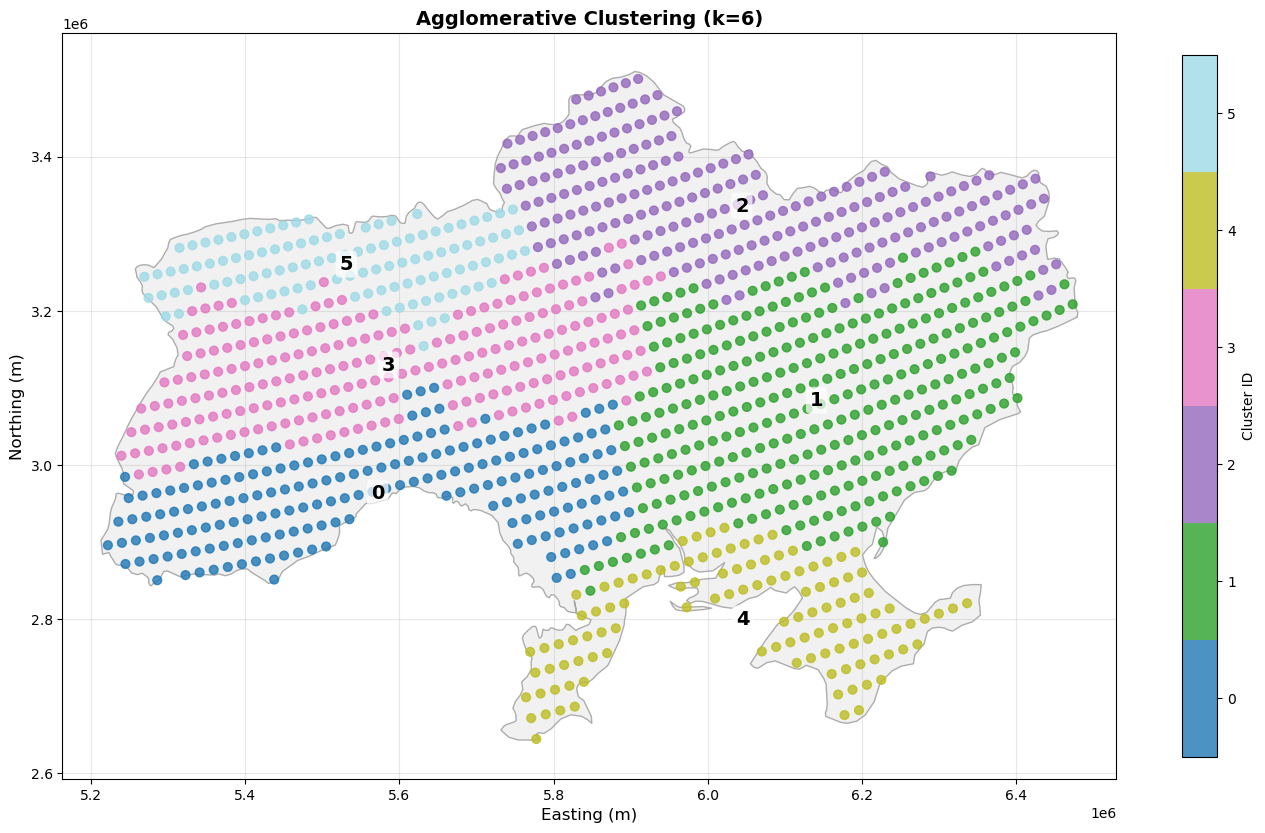

Plotted 6 clusters


In [12]:
# Plot single clustering result
fig, ax = plt.subplots(figsize=(14, 12))

# Plot Ukraine boundary
ukr_boundary.plot(ax=ax, color='lightgrey', edgecolor='black', alpha=0.3, zorder=1)

# Get unique cluster IDs
unique_clusters = np.sort(np.unique(cluster_labels))
n_clusters = len(unique_clusters)

# Create custom colormap with only the needed colors
# Create custom colormap with enough distinct colors
base_cmap = plt.cm.get_cmap('tab20', n_clusters) if n_clusters <= 20 else plt.cm.get_cmap('nipy_spectral', n_clusters)
colors = [base_cmap(i) for i in range(n_clusters)]
custom_cmap = mcolors.ListedColormap(colors)

# Create norm for the actual cluster range
norm = mcolors.Normalize(vmin=unique_clusters.min() - 0.5, vmax=unique_clusters.max() + 0.5)

scatter = ax.scatter(coords[:, 0], coords[:, 1], c=cluster_labels, cmap=custom_cmap,
                    s=40, alpha=0.8, zorder=2, norm=norm)

# Add cluster numbers at centroids
for cluster_id in np.unique(cluster_labels):
    mask = cluster_labels == cluster_id
    cx = coords[mask, 0].mean()
    cy = coords[mask, 1].mean()
    ax.text(cx, cy, str(cluster_id), fontsize=14, fontweight='bold',
           ha='center', va='center', color='black',
           bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7, edgecolor='none'),
           zorder=4)

# Set bounds
xmin, ymin, xmax, ymax = ukr_boundary.total_bounds
pad = 50000
ax.set_xlim(xmin - pad, xmax + pad)
ax.set_ylim(ymin - pad, ymax + pad)

ax.set_title(f'{clustering_type} Clustering (k={n_clusters})', fontsize=14, fontweight='bold')

ax.set_aspect('equal')
ax.set_xlabel('Easting (m)', fontsize=12)
ax.set_ylabel('Northing (m)', fontsize=12)

# Add colorbar with cluster IDs as labels
cbar = plt.colorbar(scatter, ax=ax, shrink=0.6, ticks=unique_clusters)
cbar.set_label('Cluster ID')
cbar.ax.set_yticklabels([str(int(i)) for i in unique_clusters])

ax.grid(True, alpha=0.3)
plt.tight_layout()
if save_output == True:
    plt.savefig(OUTPUT_DIR + f"clustering_k{n_clusters}.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"Plotted {len(np.unique(cluster_labels))} clusters")

In [13]:
# -------------------------
# 7. Reduce cluster to nodes and collapse edges
# -------------------------

df_cells = gdf.copy()
df_cells['cluster'] = cluster_labels

population_col = 'population'  # adjust as needed

# ------------------------------------------------------
# a) Assign cluster to cell centre 
# ------------------------------------------------------

print("a) Assigning representative cells for each cluster...")

# choose representative rule: based in geographic center
def choose_representative(cluster_df):
    """Select representative cell as closest to cluster centroid (geographic center)"""
    # Compute cluster centroid
    centroid_x = cluster_df.geometry.centroid.x.mean()
    centroid_y = cluster_df.geometry.centroid.y.mean()
    
    # Find cell closest to centroid
    distances = np.sqrt((cluster_df.geometry.centroid.x - centroid_x)**2 + 
                        (cluster_df.geometry.centroid.y - centroid_y)**2)
    rep_idx = cluster_df.index[np.argmin(distances)]
    return rep_idx

def choose_representative_pop(cluster_df):
    """Select representative cell as closest to population-weighted centroid"""
    pop = cluster_df['population'].values
    if pop.sum() == 0:
        pop = np.ones(len(cluster_df))  # fallback to equal weights if no population
    weights = pop / pop.sum()
    
    centroid_x = np.average(cluster_df.geometry.centroid.x, weights=weights)
    centroid_y = np.average(cluster_df.geometry.centroid.y, weights=weights)
    
    distances = np.sqrt((cluster_df.geometry.centroid.x - centroid_x)**2 + 
                        (cluster_df.geometry.centroid.y - centroid_y)**2)
    rep_idx = cluster_df.index[np.argmin(distances)]
    return rep_idx

cluster_groups = df_cells.groupby('cluster')
cluster_reps = {}
cluster_time_series = {}
cluster_demand = {}
cluster_land_area = {}

for c, grp in cluster_groups:
    idxs = [cell_ids.tolist().index(i) for i in grp.index]  # numeric indices
    
    # Representative: closest to cluster center
    rep_cell = choose_representative(grp)
    cluster_reps[c] = rep_cell
    
# # -------------------------------------------------------
# b) Collapse inter-cluster edges -> reduced links
# ---------------------------------------------------------

print("b) Collapsing inter-cluster edges into reduced links...")

# For each original edge (i,j) crossing clusters, map to cluster pair and compute summary stats
edge_buckets = defaultdict(list)

for i in range(n):
    for j in np.where(A_rook[i] > 0)[0]:
        ci = cluster_labels[i]
        cj = cluster_labels[j]
        if ci == cj:
            continue
        # order pair
        key = tuple(sorted((ci, cj)))
        edge_buckets[key].append((i, j))

# summarise into reduced links
reduced_links = []
for (ci, cj), edges in edge_buckets.items():
    # Get representative cells for each cluster
    rep_cell_i = cluster_reps[ci]
    rep_cell_j = cluster_reps[cj]
    
    # Get their coordinates from gdf
    coord_i = np.array([gdf.loc[rep_cell_i].geometry.centroid.x, 
                        gdf.loc[rep_cell_i].geometry.centroid.y])
    coord_j = np.array([gdf.loc[rep_cell_j].geometry.centroid.x, 
                        gdf.loc[rep_cell_j].geometry.centroid.y])
    
    # Distance between representative nodes
    distance_m = np.linalg.norm(coord_i - coord_j)
    distance_km = distance_m / 1000
    
    # Calculate mean weight across all cross-cluster edges
    mean_weight = float(np.mean([W[i,j] for i,j in edges]))
    
    link = {
        "cluster_a": ci,
        "cluster_b": cj,
        "rep_pair": (rep_cell_i, rep_cell_j),
        "n_cross_edges": len(edges),
        "mean_distance_km": distance_km,
        "mean_weight": mean_weight,
    }
    reduced_links.append(link)

a) Assigning representative cells for each cluster...
b) Collapsing inter-cluster edges into reduced links...


In [14]:
# ------------------------------------------------------
# 8. AGGREGATE CLUSTERS -> Nodal Point, Time Series, Metadata
# ------------------------------------------------------

population_col = 'population'  

# ------------------------------------------------------
# a) Create cluster-level wind and solar profiles
# ------------------------------------------------------

print("a) Aggregating wind and solar profiles by cluster...")

# Get the cell-to-cluster mapping from df_cells
cell_to_cluster = df_cells[['lon', 'lat', 'cluster','solar_cf_mean', 'wind_cf_mean']].copy()
# cell_to_cluster['location'] = cell_to_cluster['lat'].round(2).astype(str) + '_' + cell_to_cluster['lon'].round(2).astype(str)
cell_to_cluster['location'] = cell_to_cluster['lat'].map(lambda x: f"{x:.2f}") + '_' + cell_to_cluster['lon'].map(lambda x: f"{x:.2f}")
# Initialize dataframes for mean cluster profiles
cluster_wind_profile_mean = pd.DataFrame(index=hourly_wind.index)
cluster_solar_profile_mean = pd.DataFrame(index=hourly_solar.index)

# Create empty df for percentile cluster profiles (10th and 90th percentile)
cluster_wind_profile_10 = pd.DataFrame(index=hourly_wind.index)
cluster_wind_profile_50 = pd.DataFrame(index=hourly_wind.index)
cluster_wind_profile_90 = pd.DataFrame(index=hourly_wind.index)
cluster_solar_profile_10 = pd.DataFrame(index=hourly_solar.index)
cluster_solar_profile_50 = pd.DataFrame(index=hourly_solar.index)
cluster_solar_profile_90 = pd.DataFrame(index=hourly_solar.index)

# Initialise empty df for weighted cluster profiles (if needed)
cluster_wind_profile_weighted = pd.DataFrame(index=hourly_wind.index)
cluster_solar_profile_weighted = pd.DataFrame(index=hourly_solar.index)


# For each cluster, average the time series from all cells in that cluster
for cluster_id in sorted(df_cells['cluster'].unique()):
    region_cells = cell_to_cluster[cell_to_cluster['cluster'] == cluster_id]
    cells_in_cluster = region_cells['location'].tolist()
    
    # Find matching columns in wind/solar dataframes
    wind_cols = [col for col in hourly_wind.columns if col in cells_in_cluster  ]
    solar_cols = [col for col in hourly_solar.columns if col in cells_in_cluster]
    
    # Set cluster profile as mean of member cell profiles
    
    cluster_wind_profile_mean[f'cluster_{int(cluster_id)}'] = hourly_wind[wind_cols].mean(axis=1)
    cluster_solar_profile_mean[f'cluster_{int(cluster_id)}'] = hourly_solar[solar_cols].mean(axis=1)
    
    # --- NEW: Area-weighted mean ---
    # Get the cells in this cluster with their available area
    cluster_cells_full = df_cells[df_cells['cluster'] == cluster_id].copy()
    cluster_cells_full['location'] = cluster_cells_full['lat'].map(lambda x: f"{x:.2f}") + '_' + cluster_cells_full['lon'].map(lambda x: f"{x:.2f}")
    
    # Filter to cells that exist in the timeseries data
    cluster_cells_full = cluster_cells_full[cluster_cells_full['location'].isin(wind_cols)]
    
    if len(cluster_cells_full) > 0:
        # Calculate weights based on available land area
        total_available_area = cluster_cells_full['available_land_area_km2'].sum()
        
        if total_available_area > 0:
            # Create weights array matching the column order
            weights = cluster_cells_full.set_index('location')['available_land_area_km2'].reindex(wind_cols).values
            weights = weights / weights.sum()  # Normalize to sum to 1
            
            # Weighted average for wind
            cluster_wind_profile_weighted[f'cluster_{int(cluster_id)}'] = np.average(
                hourly_wind[wind_cols].values, axis=1, weights=weights
            )
            
            # Weighted average for solar (same weights since area is the same)
            solar_weights = cluster_cells_full.set_index('location')['available_land_area_km2'].reindex(solar_cols).values
            solar_weights = solar_weights / solar_weights.sum()
            cluster_solar_profile_weighted[f'cluster_{int(cluster_id)}'] = np.average(
                hourly_solar[solar_cols].values, axis=1, weights=solar_weights
            )
        else:
            # Fallback to simple mean if no available area data
            cluster_wind_profile_weighted[f'cluster_{int(cluster_id)}'] = hourly_wind[wind_cols].mean(axis=1)
            cluster_solar_profile_weighted[f'cluster_{int(cluster_id)}'] = hourly_solar[solar_cols].mean(axis=1)
    
    # Solar
    solar_cfs = region_cells['solar_cf_mean']
    solar_10 = np.percentile(solar_cfs, 10)
    solar_50 = np.percentile(solar_cfs, 50)
    solar_90 = np.percentile(solar_cfs, 90)
    solar_10_cell = region_cells.loc[(np.abs(solar_cfs - solar_10)).idxmin()]
    solar_50_cell = region_cells.loc[(np.abs(solar_cfs - solar_50)).idxmin()]
    solar_90_cell = region_cells.loc[(np.abs(solar_cfs - solar_90)).idxmin()]
    # Get timeseries for these cells (adjust as needed)
    cluster_solar_profile_10[f'cluster_{int(cluster_id)}'] = hourly_solar[solar_10_cell['location']]
    cluster_solar_profile_50[f'cluster_{int(cluster_id)}'] = hourly_solar[solar_50_cell['location']]
    cluster_solar_profile_90[f'cluster_{int(cluster_id)}'] = hourly_solar[solar_90_cell['location']]
    
    # Wind
    wind_cfs = region_cells['wind_cf_mean']
    wind_10 = np.percentile(wind_cfs, 10)
    wind_50 = np.percentile(wind_cfs, 50)
    wind_90 = np.percentile(wind_cfs, 90)
    wind_10_cell = region_cells.loc[(np.abs(wind_cfs - wind_10)).idxmin()]
    wind_50_cell = region_cells.loc[(np.abs(wind_cfs - wind_50)).idxmin()]
    wind_90_cell = region_cells.loc[(np.abs(wind_cfs - wind_90)).idxmin()]
    cluster_wind_profile_10[f'cluster_{int(cluster_id)}'] = hourly_wind[wind_10_cell['location']]
    cluster_wind_profile_50[f'cluster_{int(cluster_id)}'] = hourly_wind[wind_50_cell['location']]
    cluster_wind_profile_90[f'cluster_{int(cluster_id)}'] = hourly_wind[wind_90_cell['location']]
    
# Zero tiny weighted CF values to avoid downstream coefficient magnitude issues

if floor_timeseries == True:
    cf_floor = 1e-4
    cluster_wind_profile_weighted = cluster_wind_profile_weighted.mask(cluster_wind_profile_weighted < cf_floor, 0.0)
    cluster_solar_profile_weighted = cluster_solar_profile_weighted.mask(cluster_solar_profile_weighted < cf_floor, 0.0)

print("   Cluster wind profiles (mean, 10th, 50th, 90th percentile) created.")       
print("   Cluster solar profiles (mean, 10th, 50th, 90th percentile) created.")
    
# ------------------------------------------------------
# b) Create cluster demand profiles from national data
# ------------------------------------------------------

print("b) Creating cluster electricity demand profiles from national data...")

# Load national hourly demand data
national_demand_path = '../../../data_prep/data/time_series_60min_singleindex.csv'

print(f"   Loading national demand from: {national_demand_path}")
national_df = pd.read_csv(national_demand_path, parse_dates=['utc_timestamp'], low_memory=False)

# Select and rename columns
national_df = national_df[['utc_timestamp', 'UA_load_actual_entsoe_transparency']].copy()
national_df.rename(columns={
    'utc_timestamp': 'datetime',
    'UA_load_actual_entsoe_transparency': 'national_MWh'
}, inplace=True)

# Clean and remove timezone info to match wind/solar index
national_df['datetime'] = pd.to_datetime(national_df['datetime'], errors='coerce')
national_df['datetime'] = national_df['datetime'].dt.tz_localize(None)  # Remove UTC timezone
national_df = national_df.dropna(subset=['datetime', 'national_MWh']).reset_index(drop=True)

# Filter to 2023 to match wind/solar profiles
target_year = cluster_wind_profile_mean.index[0].year
print(f"   Filtering national demand to year {target_year}...")

# If 2023 data doesn't exist, use 2019 data and shift the year
available_years = national_df['datetime'].dt.year.unique()
print(f"   Available years in national demand: {sorted(available_years)}")

if target_year in available_years:
    national_df = national_df[national_df['datetime'].dt.year == target_year].reset_index(drop=True)
else:
    # Use 2019 data and shift to target year
    print(f"   {target_year} not available, using 2019 pattern and shifting to {target_year}")
    national_df = national_df[national_df['datetime'].dt.year == 2019].reset_index(drop=True)
    national_df['datetime'] = national_df['datetime'].apply(lambda t: t.replace(year=target_year))

# Set datetime as index (now timezone-naive, matching wind/solar)
national_df = national_df.set_index('datetime')

# Calculate total national energy (MWh)
national_total_MWh = national_df['national_MWh'].sum()

# Calculate cluster demand shares based on population
cluster_populations = df_cells.groupby('cluster')[population_col].sum()
total_population = cluster_populations.sum()

# Calculate population proportion for each cluster
cluster_pop_share = cluster_populations / total_population
# Create cluster demand profiles by scaling national profile by population share
cluster_demand_profile = pd.DataFrame(index=cluster_wind_profile_mean.index)

# Align national demand with wind/solar time index
if len(national_df) != len(cluster_wind_profile_mean):
    print(f"   Warning: National demand has {len(national_df)} timesteps, wind/solar have {len(cluster_wind_profile_mean)}")
    print(f"   Reindexing national demand to match wind/solar timestamps...")
    national_df = national_df.reindex(cluster_wind_profile_mean.index, method='nearest')

for cluster_id in sorted(df_cells['cluster'].unique()):
    region_col = f'cluster_{int(cluster_id)}'
    # Scale national demand by regional population share
    cluster_demand_profile[region_col] = -1*national_df['national_MWh'] * cluster_pop_share[cluster_id]

cluster_demand_profile.index = cluster_demand_profile.index.strftime('%Y-%m-%d %H:%M:%S')

# ------------------------------------------------------
# c) Create ammonia demand profiles for each cluster
# ------------------------------------------------------

print("c) Defining ammonia demand by cluster...")

# Ammonia demand proportional to population (tonnes per year)
ammonia_df = df_cells.groupby('cluster')['ammonia_demand_mwh'].sum().reset_index()
print(ammonia_df.head())
ammonia_np = ammonia_df['ammonia_demand_mwh'].values
print(ammonia_np)

# -----------------------------------------------------
# d) Create metadata for each cluster
# -----------------------------------------------------

print("d) Creating cluster metadata...")

# Initialize metadata dictionary
cluster_metadata_list = []

for cluster_id in sorted(df_cells['cluster'].unique()):
    cluster_cells = df_cells[df_cells['cluster'] == cluster_id]
    
    # Get representative cell
    rep_cell = cluster_reps[cluster_id]
    rep_row = df_cells.loc[rep_cell]
    
    # Aggregate cluster-level statistics
    pop_sum = cluster_cells['population'].sum()
    total_land_area = cluster_cells['area_km2'].sum()
    available_land_area = cluster_cells['available_land_area_km2'].sum()
    lat = rep_row['lat']
    lon = rep_row['lon']
    
    # Get ammonia demand from ammonia_df
    # ammonia_demand_val = ammonia_df[f'cluster_{int(cluster_id)}'].values[0]
    
    # Create metadata row
    cluster_metadata_list.append({
        'cluster_id': int(cluster_id),
        'lat': lat,
        'lon': lon,
        'population': pop_sum,
        'land_area_km2': total_land_area,
        'available_land_area_km2': available_land_area,
        'ammonia_demand_MWh_hourly': ammonia_np[int(cluster_id)]/8760  # convert annual MWh to hourly
    })

# Create metadata DataFrame
cluster_metadata_df = pd.DataFrame(cluster_metadata_list)

# Sort by cluster_id
cluster_metadata_df = cluster_metadata_df.sort_values('cluster_id').reset_index(drop=True)

print(cluster_metadata_df.head())

a) Aggregating wind and solar profiles by cluster...
   Cluster wind profiles (mean, 10th, 50th, 90th percentile) created.
   Cluster solar profiles (mean, 10th, 50th, 90th percentile) created.
b) Creating cluster electricity demand profiles from national data...
   Loading national demand from: ../../../data_prep/data/time_series_60min_singleindex.csv
   Filtering national demand to year 2023...
   Available years in national demand: [np.int32(2017), np.int32(2018), np.int32(2019), np.int32(2020)]
   2023 not available, using 2019 pattern and shifting to 2023
   Reindexing national demand to match wind/solar timestamps...
c) Defining ammonia demand by cluster...
   cluster  ammonia_demand_mwh
0        0                0.00
1        1                0.00
2        2                0.00
3        3          6953226.26
4        4          6234273.73
[      0.         0.         0.   6953226.26 6234273.73       0.  ]
d) Creating cluster metadata...
   cluster_id    lat    lon  population  l

In [15]:
# ---------------------------------------------
# 9. SAVE OUTPUTS
# ---------------------------------------------

import os

if save_output:
    print(f"Saving outputs to: {OUTPUT_DIR}")

    # Save Metadata

    print("\na) Saving metadata...")
    cluster_metadata_df.to_csv(OUTPUT_DIR+"cluster_metadata.csv")
    print(f"   ✓ Saved: cluster_metadata.csv")

    # b) Save Time Series - Wind & Solar Profiles

    print("\nb) Saving renewable energy profiles...")


    mean_dir = OUTPUT_DIR+"mean_percentile_timeseries/"
    os.makedirs(mean_dir, exist_ok=True)
    cluster_wind_profile_mean.to_csv(mean_dir+"cluster_wind_profiles_mean.csv")
    print("✓ Saved: cluster_wind_profiles_mean.csv")
    cluster_solar_profile_mean.to_csv(mean_dir+"cluster_solar_profiles_mean.csv")
    print("✓ Saved: cluster_solar_profiles_mean.csv")

    weighted_dir = OUTPUT_DIR+"weighted_percentile_timeseries/"
    os.makedirs(weighted_dir, exist_ok=True)
    cluster_wind_profile_weighted.to_csv(weighted_dir+"cluster_wind_profiles_weighted.csv")
    print("✓ Saved: cluster_wind_profiles_weighted.csv")
    cluster_solar_profile_weighted.to_csv(weighted_dir+"cluster_solar_profiles_weighted.csv")
    print("✓ Saved: cluster_solar_profiles_weighted.csv")

    ten_percentile_dir = OUTPUT_DIR+"10_percentile_timeseries/"
    os.makedirs(ten_percentile_dir, exist_ok=True)
    cluster_wind_profile_10.to_csv(ten_percentile_dir+"cluster_wind_profiles_10th.csv")
    print("✓ Saved: cluster_wind_profiles_10th.csv")
    cluster_solar_profile_10.to_csv(ten_percentile_dir+"cluster_solar_profiles_10th.csv")
    print(f"✓ Saved: cluster_solar_profiles_10th.csv")

    fifty_percentile_dir = OUTPUT_DIR+"50_percentile_timeseries/"
    os.makedirs(fifty_percentile_dir, exist_ok=True)
    cluster_wind_profile_50.to_csv(fifty_percentile_dir+"cluster_wind_profiles_50th.csv")
    print("✓ Saved: cluster_wind_profiles_50th.csv")
    cluster_solar_profile_50.to_csv(fifty_percentile_dir+"cluster_solar_profiles_50th.csv")
    print("✓ Saved: cluster_solar_profiles_50th.csv")

    ninety_percentile_dir = OUTPUT_DIR+"90_percentile_timeseries/"
    os.makedirs(ninety_percentile_dir, exist_ok=True)
    cluster_wind_profile_90.to_csv(ninety_percentile_dir+"cluster_wind_profiles_90th.csv")
    print("✓ Saved: cluster_wind_profiles_90th.csv")    
    cluster_solar_profile_90.to_csv(ninety_percentile_dir+"cluster_solar_profiles_90th.csv")
    print("✓ Saved: cluster_solar_profiles_90th.csv")


    # c) Save Electricity Demand Profiles
    print("\nc) Saving demand profiles...")
    cluster_demand_profile.to_csv(OUTPUT_DIR+"cluster_demand_profiles.csv")
    print(f"   ✓ Saved: cluster_demand_profiles.csv")

    # d) Save Network Interconnections

    print("\nd) Saving network interconnections...")

    # Save reduced links (cluster-to-cluster connections)
    reduced_links_df = pd.DataFrame(reduced_links)
    reduced_links_df.to_csv(OUTPUT_DIR+"reduced_links.csv")
    print(f"   ✓ Saved: reduced_links.csv ({len(reduced_links)} links)")

    # Save cluster representatives
    pd.Series(cluster_reps, name='rep_cell').to_csv(OUTPUT_DIR+"cluster_reps.csv", header=True)
    print(f"   ✓ Saved: cluster_reps.csv")

    # Save cell-to-cluster mapping
    pd.Series(cluster_labels, index=cell_ids, name='cluster').to_csv(OUTPUT_DIR+"cell_to_cluster_mapping.csv")
    print(f"   ✓ Saved: cell_to_cluster_mapping.csv")


    # f) Save GeoJSON with clusters

    print("\nf) Saving spatial data...")
    df_cells.to_file(OUTPUT_DIR+"clusters_geodata.geojson", driver="GeoJSON")
    print(f"   ✓ Saved: clusters_geodata.geojson")


    # g) Save Summary Statistics

    print("\ng) Saving summary statistics...")
    summary_stats = {
    'n_clusters': len(cluster_metadata_df),
    'n_cells': len(df_cells),
    'n_interconnections': len(reduced_links),
    'total_population': float(cluster_metadata_df['population'].sum()),
    'total_land_area_km2': float(cluster_metadata_df['available_land_area_km2'].sum()),
    'total_ammonia_demand_MWh_per_hour': float(cluster_metadata_df['ammonia_demand_MWh_hourly'].sum()),
    'clustering_method': 'Spectral',
    'k_neighbors': K_NEIGHBORS,
    'alpha': ALPHA,
    'beta_attr': BETA_ATTR
    }

    summary_df = pd.DataFrame([summary_stats])
    summary_df.to_csv(OUTPUT_DIR+"summary_statistics.csv", index=False)
    print(f"   ✓ Saved: summary_statistics.csv")

    # Print summary
    print("\n" + "="*60)
    print("OUTPUTS SUMMARY")
    print("="*60)
    for key, value in summary_stats.items():
        print(f"  {key}: {value}")
    print("="*60)

    print(f"\n✓ All outputs saved to: {OUTPUT_DIR}/")

NameError: name 'OUTPUT_DIR' is not defined

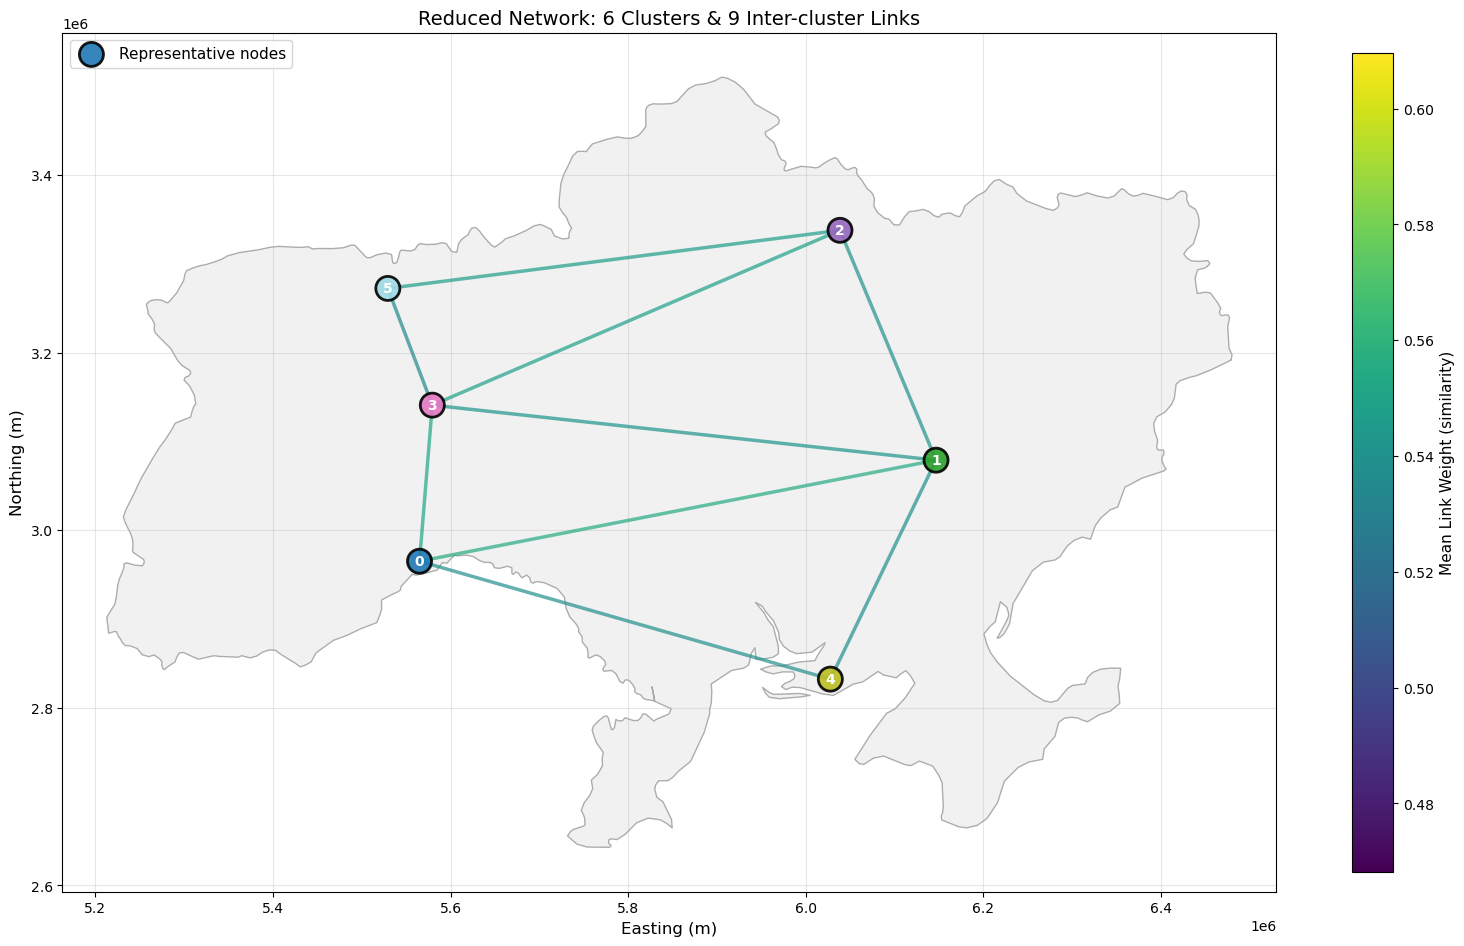

In [16]:
# ---------------------------------------------
# 10. PLOT REPRESENTATIVE NODES & CLUSTER LINKS 
# ---------------------------------------------

# Load Ukraine boundary
UKR_SHP = "../../../data_prep/data/ukraine_merged_dissolved_noholes.geojson"
ukr_boundary = gpd.read_file(UKR_SHP).to_crs(CRS_METRIC)

# Get representative cell coordinates
rep_cells_list = list(cluster_reps.values())
rep_gdf = gdf.loc[rep_cells_list].copy()
rep_coords = np.vstack([rep_gdf.geometry.centroid.x, rep_gdf.geometry.centroid.y]).T

# Create figure
fig, ax = plt.subplots(figsize=(16, 12))

# Plot Ukraine boundary
ukr_boundary.plot(ax=ax, color='lightgrey', edgecolor='black', alpha=0.3, zorder=1)

# Plot cluster links using cluster_reps directly
link_weights = []
for link in reduced_links:
    cluster_a = link['cluster_a']
    cluster_b = link['cluster_b']
    
    # Get representative cells for each cluster
    rep_cell_a = cluster_reps[cluster_a]
    rep_cell_b = cluster_reps[cluster_b]
    
    # Get coordinates
    coord_a = gdf.loc[rep_cell_a].geometry.centroid.coords[0]
    coord_b = gdf.loc[rep_cell_b].geometry.centroid.coords[0]
    
    weight = link['mean_weight']
    link_weights.append(weight)
    
    # Plot link
    ax.plot([coord_a[0], coord_b[0]], [coord_a[1], coord_b[1]], 
            color=plt.cm.viridis(weight), linewidth=2.5, alpha=0.7, zorder=2)

# Plot representative nodes colored by cluster
cluster_ids = np.array(list(cluster_reps.keys()))
scatter = ax.scatter(rep_coords[:, 0], rep_coords[:, 1], c=cluster_ids, cmap='tab20', 
                     s=300, alpha=0.9, edgecolors='black', linewidth=2, zorder=3,
                     label='Representative nodes')

# Add cluster labels on representative nodes
for cluster_id, rep_cell in cluster_reps.items():
    coord = gdf.loc[rep_cell].geometry.centroid.coords[0]
    ax.text(coord[0], coord[1], str(cluster_id), fontsize=10, fontweight='bold',
           ha='center', va='center', color='white', zorder=4)

# Set bounds to Ukraine extent
xmin, ymin, xmax, ymax = ukr_boundary.total_bounds
pad = 50000
ax.set_xlim(xmin - pad, xmax + pad)
ax.set_ylim(ymin - pad, ymax + pad)

# Add colorbar for link weights
if link_weights:
    sm = plt.cm.ScalarMappable(cmap=plt.cm.viridis, 
                               norm=plt.Normalize(vmin=min(link_weights), vmax=max(link_weights)))
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, shrink=0.7)
    cbar.set_label('Mean Link Weight (similarity)', fontsize=11)

ax.set_xlabel('Easting (m)', fontsize=12)
ax.set_ylabel('Northing (m)', fontsize=12)
ax.set_title(f'Reduced Network: {len(cluster_reps)} Clusters & {len(reduced_links)} Inter-cluster Links', fontsize=14)
ax.legend(loc='upper left', fontsize=11)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR + "representative_network_rook.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"Plotted {len(cluster_reps)} representative nodes")
print(f"Plotted {len(reduced_links)} inter-cluster links")
if link_weights:
    print(f"Link weight range: {min(link_weights):.4f} - {max(link_weights):.4f}")

# ---------------------------------------------
# 10. PLOT REPRESENTATIVE NODES & Reduced CLUSTER LINKS 
# ---------------------------------------------

import networkx as nx

# Number of extra high-weight links to add beyond the MST
n_extra_links = 10

# Build graph from reduced_links_df
reduced_links_df['total_edge_weight'] = reduced_links_df['n_cross_edges'] * reduced_links_df['mean_weight']

G = nx.Graph()
for _, row in reduced_links_df.iterrows():
    # Use inverse of mean_weight so MST keeps the strongest connections
    G.add_edge(row['cluster_a'], row['cluster_b'], 
               weight=1.0 / row['mean_weight'], 
               data=row.to_dict())

# Compute MST - guarantees all clusters are connected
mst = nx.minimum_spanning_tree(G)
mst_edge_set = {(min(u, v), max(u, v)) for u, v in mst.edges()}

# Identify MST rows in the dataframe
def is_mst_edge(row):
    key = (min(row['cluster_a'], row['cluster_b']), max(row['cluster_a'], row['cluster_b']))
    return key in mst_edge_set

mst_mask = reduced_links_df.apply(is_mst_edge, axis=1)
mst_links_df = reduced_links_df[mst_mask]

# Add top n_extra_links non-MST edges by total_edge_weight
non_mst_links_df = reduced_links_df[~mst_mask].nlargest(n_extra_links, 'total_edge_weight')

# Combine MST + extras
reduced_reduced_links_df = pd.concat([mst_links_df, non_mst_links_df]).sort_values(
    'total_edge_weight', ascending=False).reset_index(drop=True)
reduced_reduced_links = reduced_reduced_links_df.to_dict('records')

print(f"MST links: {len(mst_links_df)}, Extra links: {len(non_mst_links_df)}, Total: {len(reduced_reduced_links)}")
# Create figure
fig, ax = plt.subplots(figsize=(16, 12))

# Plot Ukraine boundary
ukr_boundary.plot(ax=ax, color='lightgrey', edgecolor='black', alpha=0.3, zorder=1)

# Plot cluster links using cluster_reps directly
link_weights = []
for link in reduced_reduced_links:
    cluster_a = link['cluster_a']
    cluster_b = link['cluster_b']
    
    # Get representative cells for each cluster
    rep_cell_a = cluster_reps[cluster_a]
    rep_cell_b = cluster_reps[cluster_b]
    
    # Get coordinates
    coord_a = gdf.loc[rep_cell_a].geometry.centroid.coords[0]
    coord_b = gdf.loc[rep_cell_b].geometry.centroid.coords[0]
    
    weight = link['mean_weight']
    link_weights.append(weight)
    
    # Plot link
    ax.plot([coord_a[0], coord_b[0]], [coord_a[1], coord_b[1]], 
            color=plt.cm.viridis(weight), linewidth=2.5, alpha=0.7, zorder=2)

# Plot representative nodes colored by cluster
cluster_ids = np.array(list(cluster_reps.keys()))
scatter = ax.scatter(rep_coords[:, 0], rep_coords[:, 1], c=cluster_ids, cmap='tab20', 
                     s=300, alpha=0.9, edgecolors='black', linewidth=2, zorder=3,
                     label='Representative nodes')

# Add cluster labels on representative nodes
for cluster_id, rep_cell in cluster_reps.items():
    coord = gdf.loc[rep_cell].geometry.centroid.coords[0]
    ax.text(coord[0], coord[1], str(cluster_id), fontsize=10, fontweight='bold',
           ha='center', va='center', color='white', zorder=4)

# Set bounds to Ukraine extent
xmin, ymin, xmax, ymax = ukr_boundary.total_bounds
pad = 50000
ax.set_xlim(xmin - pad, xmax + pad)
ax.set_ylim(ymin - pad, ymax + pad)

# Add colorbar for link weights
if link_weights:
    sm = plt.cm.ScalarMappable(cmap=plt.cm.viridis, 
                               norm=plt.Normalize(vmin=min(link_weights), vmax=max(link_weights)))
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, shrink=0.7)
    cbar.set_label('Mean Link Weight (similarity)', fontsize=11)

ax.set_xlabel('Easting (m)', fontsize=12)
ax.set_ylabel('Northing (m)', fontsize=12)
ax.set_title(f'Reduced Reduced Network: {len(cluster_reps)} Clusters & {len(reduced_reduced_links)} Inter-cluster Links', fontsize=14)
ax.legend(loc='upper left', fontsize=11)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)

plt.tight_layout()
# plt.savefig(OUTPUT_DIR + "reduced_representative_network_rook.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"Plotted {len(cluster_reps)} representative nodes")
print(f"Plotted {len(reduced_reduced_links)} inter-cluster links")
if link_weights:
    print(f"Link weight range: {min(link_weights):.4f} - {max(link_weights):.4f}")
    
# reduced_reduced_links_df.to_csv(OUTPUT_DIR+"reduced_reduced_links.csv")

# ============================================================
# 2×2 Methodology Figure: Data → Clusters → Centroids → Network
# ============================================================

from matplotlib.patches import FancyArrowPatch

UKR_BOUNDARY = "../../../data_prep/data/ukraine_merged_dissolved_noholes.geojson"
CLUSTER_DIR = OUTPUT_DIR  # Directory where cluster outputs are saved

# --- Load data ---
ukr = gpd.read_file(UKR_BOUNDARY).to_crs(CRS_METRIC)
mapping = cluster_labels  # cell_id to cluster_id mapping
metadata = pd.read_csv(CLUSTER_DIR + "cluster_metadata.csv")
links = pd.read_csv(CLUSTER_DIR + "reduced_links.csv")

# read from in-memory variables instead of CSV for faster plotting (if available)
# metadata = cluster_metadata_df.copy()
# links = pd.DataFrame(reduced_links)  # Use in-memory reduced_links list instead of reading from CSV

# Assign clusters to cells (gdf must exist from earlier cells)
cells = gdf.copy()
cells['cluster'] = mapping

# Centroids in metric CRS
centroids_gdf = gpd.GeoDataFrame(
    metadata, geometry=gpd.points_from_xy(metadata['lon'], metadata['lat']),
    crs="EPSG:4326"
).to_crs(CRS_METRIC)

# Colour map
n_clust = len(metadata)
cmap = plt.cm.get_cmap('tab20', n_clust)
cluster_colors = {row['cluster_id']: cmap(i) for i, (_, row) in enumerate(metadata.iterrows())}

# --- Figure ---
fig, axes = plt.subplots(2, 2, figsize=(14, 11))

xmin, ymin, xmax, ymax = ukr.total_bounds
pad = 30000

def set_bounds(ax):
    ax.set_xlim(xmin - pad, xmax + pad)
    ax.set_ylim(ymin - pad, ymax + pad)
    ax.set_aspect('equal')
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

# (a) Gridded data
ax = axes[0, 0]
ukr.plot(ax=ax, color='#f0f0f0', edgecolor='black', linewidth=1.2, zorder=1)
cells.plot(ax=ax, facecolor='none', edgecolor='#4a90d9', linewidth=0.15, alpha=0.6, zorder=2)
ax.set_title('(a) Gridded data', fontsize=13, fontweight='bold', pad=8)
set_bounds(ax)

# (b) Clustered regions
ax = axes[0, 1]
ukr.plot(ax=ax, color='#f0f0f0', edgecolor='black', linewidth=1.2, zorder=1)
for cid, color in cluster_colors.items():
    cells[cells['cluster'] == cid].plot(ax=ax, color=color, edgecolor='white', linewidth=0.1, alpha=0.85, zorder=2)
dissolved = cells.dissolve(by='cluster').reset_index()
dissolved.boundary.plot(ax=ax, color='black', linewidth=0.6, zorder=3)
ax.set_title('(b) Spatial clusters', fontsize=13, fontweight='bold', pad=8)
set_bounds(ax)

# (c) Cluster centroids
ax = axes[1, 0]
ukr.plot(ax=ax, color='#f0f0f0', edgecolor='black', linewidth=1.2, zorder=1)
dissolved.plot(ax=ax, facecolor='none', edgecolor='grey', linewidth=0.4, alpha=0.5, zorder=2)
for _, row in centroids_gdf.iterrows():
    ax.scatter(row.geometry.x, row.geometry.y, c=[cluster_colors[row['cluster_id']]],
               s=80, edgecolors='black', linewidth=0.8, zorder=4)
ax.set_title('(c) Cluster centroids', fontsize=13, fontweight='bold', pad=8)
set_bounds(ax)

# (d) Network construction
ax = axes[1, 1]
ukr.plot(ax=ax, color='#f0f0f0', edgecolor='black', linewidth=1.2, zorder=1)
centroid_coords = {row['cluster_id']: (row.geometry.x, row.geometry.y) for _, row in centroids_gdf.iterrows()}
for _, link in links.iterrows():
    ca, cb = int(link['cluster_a']), int(link['cluster_b'])
    if ca in centroid_coords and cb in centroid_coords:
        xa, ya = centroid_coords[ca]
        xb, yb = centroid_coords[cb]
        ax.plot([xa, xb], [ya, yb], color='#555555', linewidth=1.0, alpha=0.6, zorder=2)
for cid, (cx, cy) in centroid_coords.items():
    ax.scatter(cx, cy, c=[cluster_colors[cid]], s=80, edgecolors='black', linewidth=0.8, zorder=4)
ax.set_title('(d) Network construction', fontsize=13, fontweight='bold', pad=8)
set_bounds(ax)

# --- Arrows between panels ---
arrow_props = dict(arrowstyle='->', color='#333333', linewidth=2.0, mutation_scale=20)

# (a) → (b)
fig.patches.append(FancyArrowPatch(
    (0.48, 0.72), (0.52, 0.72), transform=fig.transFigure, **arrow_props))
# (b) → (c) diagonal
fig.patches.append(FancyArrowPatch(
    (0.48, 0.50), (0.52, 0.50), transform=fig.transFigure,
    connectionstyle='arc3,rad=-0.3', **arrow_props))
# (c) → (d)
fig.patches.append(FancyArrowPatch(
    (0.48, 0.30), (0.52, 0.30), transform=fig.transFigure, **arrow_props))

plt.tight_layout(w_pad=3, h_pad=2)
fig.savefig("../../../4YP_Figures/clustering_methodology_2x2_pop.png", dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

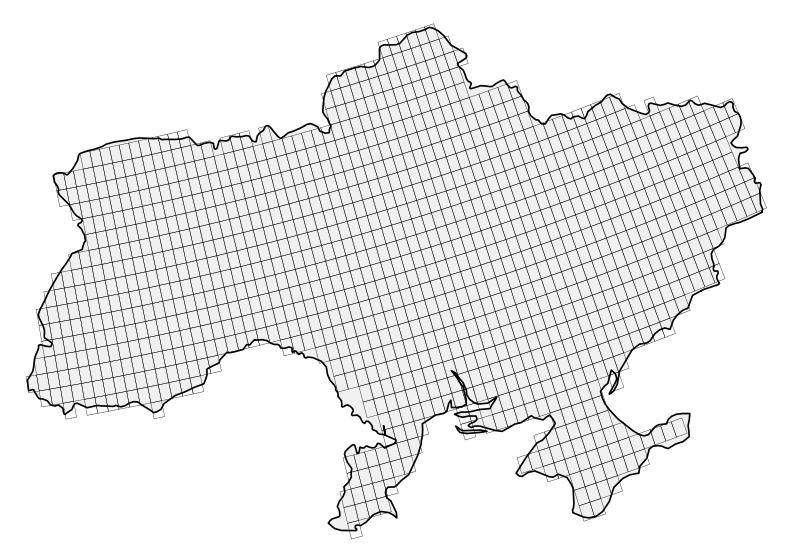

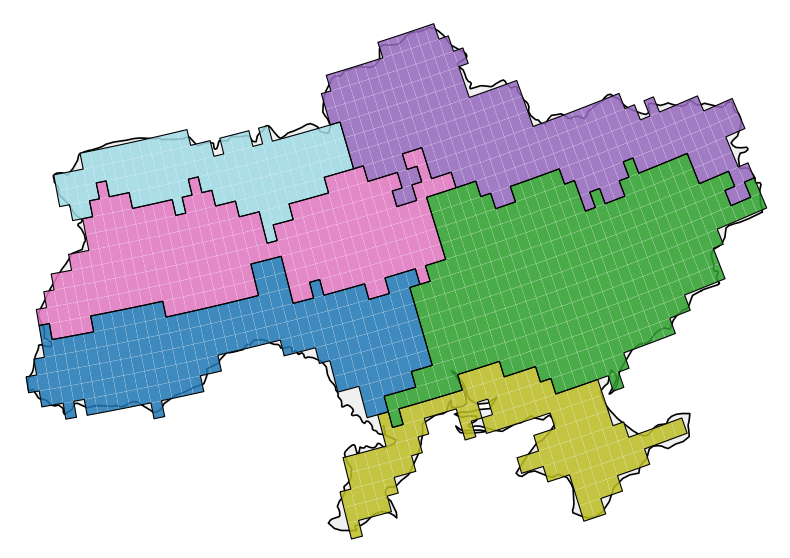

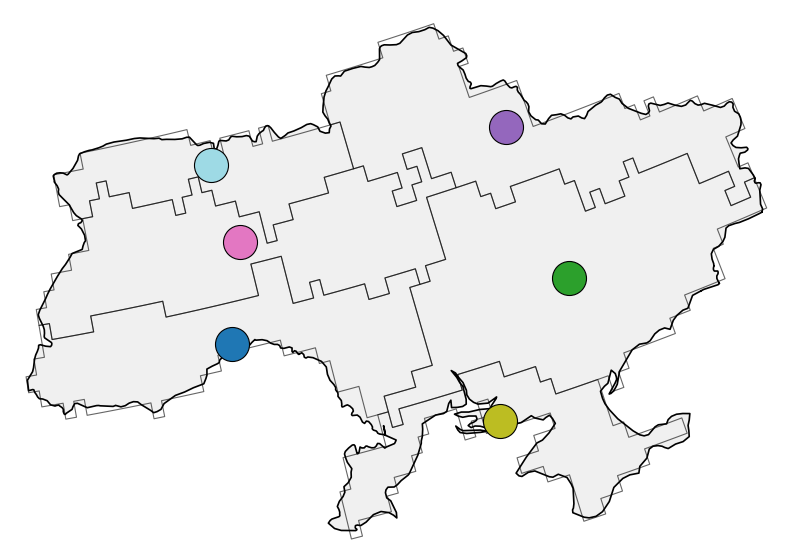

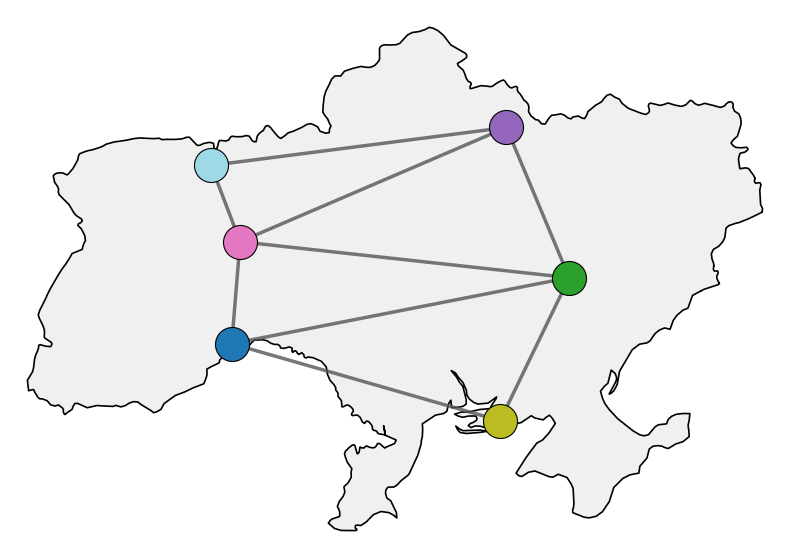

Saved 4 panels to ../../../4YP_Figures/


In [23]:
# ============================================================
# Individual methodology panels for PowerPoint
# ============================================================

from matplotlib.patches import FancyArrowPatch

UKR_BOUNDARY = "../../../data_prep/data/ukraine_merged_dissolved_noholes.geojson"

ukr = gpd.read_file(UKR_BOUNDARY).to_crs(CRS_METRIC)
cells = gdf.copy()
cells['cluster'] = cluster_labels

CLUSTER_DIR = f"../../../data_prep/Clustering_Output/KNN_Graph_output/nodal_ammonia_bidirectional/{clustering_type}/{clustering_type}_k{n_clusters_target}/"

metadata = pd.read_csv(CLUSTER_DIR + "cluster_metadata.csv")
links = pd.read_csv(CLUSTER_DIR + "reduced_links.csv")

centroids_gdf = gpd.GeoDataFrame(
    metadata,
    geometry=gpd.points_from_xy(metadata['lon'], metadata['lat']),
    crs="EPSG:4326"
).to_crs(CRS_METRIC)


n_clust = len(metadata)
cmap = plt.cm.get_cmap('tab20', n_clust)
cluster_colors = {row['cluster_id']: cmap(i) for i, (_, row) in enumerate(metadata.iterrows())}

xmin, ymin, xmax, ymax = ukr.total_bounds
pad = 30000

def set_bounds(ax):
    ax.set_xlim(xmin - pad, xmax + pad)
    ax.set_ylim(ymin - pad, ymax + pad)
    ax.set_aspect('equal')
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

SAVE_DIR = "../../../4YP_Figures/"

# --- (a) Gridded data ---
fig, ax = plt.subplots(figsize=(8, 6))
ukr.plot(ax=ax, color='#f0f0f0', edgecolor='black', linewidth=1.2, zorder=1)
cells.plot(ax=ax, facecolor='none', edgecolor = 'black', linewidth=0.3, alpha=0.9, zorder=2)
set_bounds(ax)
plt.tight_layout()
fig.savefig(SAVE_DIR + "methodology_a_gridded_data.png", dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

# --- (b) Spatial clusters ---
fig, ax = plt.subplots(figsize=(8, 6))
ukr.plot(ax=ax, color='#f0f0f0', edgecolor='black', linewidth=1.2, zorder=1)
for cid, color in cluster_colors.items():
    cells[cells['cluster'] == cid].plot(ax=ax, color=color, edgecolor='white', linewidth=0.1, alpha=0.85, zorder=2)
dissolved = cells.dissolve(by='cluster').reset_index()
dissolved.boundary.plot(ax=ax, color='black', linewidth=0.8, zorder=3)
set_bounds(ax)
plt.tight_layout()
fig.savefig(SAVE_DIR + "methodology_b_spatial_clusters.png", dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

# --- (c) Cluster centroids ---
fig, ax = plt.subplots(figsize=(8, 6))
ukr.plot(ax=ax, color='#f0f0f0', edgecolor='black', linewidth=1.2, zorder=1)
dissolved.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=0.8, alpha=0.6, zorder=2)
for _, row in centroids_gdf.iterrows():
    ax.scatter(row.geometry.x, row.geometry.y, c=[cluster_colors[row['cluster_id']]],
               s=600, edgecolors='black', linewidth=0.8, zorder=4)
set_bounds(ax)
plt.tight_layout()
fig.savefig(SAVE_DIR + "methodology_c_centroids.png", dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

# --- (d) Network construction ---
fig, ax = plt.subplots(figsize=(8, 6))
ukr.plot(ax=ax, color='#f0f0f0', edgecolor='black', linewidth=1.2, zorder=1)
centroid_coords = {row['cluster_id']: (row.geometry.x, row.geometry.y) for _, row in centroids_gdf.iterrows()}
for _, link in links.iterrows():
    ca, cb = int(link['cluster_a']), int(link['cluster_b'])
    if ca in centroid_coords and cb in centroid_coords:
        xa, ya = centroid_coords[ca]
        xb, yb = centroid_coords[cb]
        ax.plot([xa, xb], [ya, yb], color='#555555', linewidth=2.5, alpha=0.8, zorder=2)
for cid, (cx, cy) in centroid_coords.items():
    ax.scatter(cx, cy, c=[cluster_colors[cid]], s=600, edgecolors='black', linewidth=0.8, zorder=4)
set_bounds(ax)
plt.tight_layout()
fig.savefig(SAVE_DIR + "methodology_d_network.png", dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print(f"Saved 4 panels to {SAVE_DIR}")